# ANALISIS KOMPARATIF MODEL FUSI TIME SERIES, SENTIMEN, DAN ON-CHAIN
**Stanyslaus Hary Muntoro (220712140)**  
Universitas Atma Jaya Yogyakarta — 2025/2026

### Deskripsi
Notebook ini mengimplementasikan eksperimen utama penelitian:
- 8 model: LSTM-Price, LSTM-Sentiment, LSTM-OnChain, LSTM-Full, GRU-Price, GRU-Sentiment, GRU-OnChain, GRU-Full
- 3 aset kripto: BTC, ETH, SOL
- Evaluasi metrik: RMSE, MAE, MAPE, R²

## 1. Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, skew, wilcoxon
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools
import os

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, GRU, Dense, Dropout,
    Flatten, Concatenate
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
import sys
print(sys.version)

TensorFlow: 2.18.0
Pandas: 2.3.3
Numpy: 2.2.6
3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:16:49) [GCC 13.3.0]


## 2. Data Preparation

### 2a. Import Data Sentimen dan On-chain

In [62]:
# Load CSV Santiment
btc = pd.read_csv('BTC_sentiment_onchain.csv')
eth = pd.read_csv('ETH_sentiment_onchain.csv')
sol = pd.read_csv('SOL_sentiment_onchain.csv')

# Cek shape dan kolom
for name, df in [('BTC', btc), ('ETH', eth), ('SOL', sol)]:
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Date range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
    print()

=== BTC ===
Shape: (2173, 14)
Columns: ['Date', 'Positive sentiment (Total)', 'Negative sentiment (Total)', 'Weighted sentiment (Total)', 'Social Dominance', 'Active Addresses 24h', 'MVRV Ratio (1d)', 'NVT Ratio (with Transaction Volume)', 'Supply on Exchanges', 'Whale Transaction Count (>100k USD)', 'Percent of Stablecoin Total Supply held by Whales with more than 5 million USD', 'Development Activity', 'Transaction Volume', 'Network Growth']
Date range: 2020-04-02T00:00:00.000Z to 2026-03-19T00:00:00.000Z

=== ETH ===
Shape: (2173, 14)
Columns: ['Date', 'Social Dominance (ETH)', 'Positive sentiment (Total) (ETH)', 'Negative sentiment (Total) (ETH)', 'Weighted sentiment (Total) (ETH)', 'Development Activity (ETH)', 'MVRV Ratio (1d) (ETH)', 'NVT Ratio (with Transaction Volume) (ETH)', 'Active Addresses 24h (ETH)', 'Supply on Exchanges (ETH)', 'Whale Transaction Count (>100k USD) (ETH)', 'Percent of Stablecoin Total Supply held by Whales with more than 5 million USD', 'Transaction Volum

### 2b. Cleaning dan Standarisasi Data

In [64]:
# Parse date
for df in [btc, eth, sol]:
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.normalize()

# === BTC: memilih kolom yang dipakai ===
btc_clean = btc[[
    'Date',
    'Positive sentiment (Total)',
    'Negative sentiment (Total)',
    'Social Dominance',
    'Active Addresses 24h',
    'Percent of Stablecoin Total Supply held by Whales with more than 5 million USD',
    'Development Activity',
    'Transaction Volume',
    'Network Growth'
]].copy()

btc_clean.columns = [
    'Date',
    'sentiment_positive', 'sentiment_negative', 'social_dominance',
    'active_addresses', 'whale_stablecoin_pct',
    'dev_activity', 'transaction_volume', 'network_growth'
]

# === ETH: memilih kolom yang dipakai ===
eth_clean = eth[[
    'Date',
    'Positive sentiment (Total) (ETH)',
    'Negative sentiment (Total) (ETH)',
    'Social Dominance (ETH)',
    'Active Addresses 24h (ETH)',
    'Percent of Stablecoin Total Supply held by Whales with more than 5 million USD',
    'Development Activity (ETH)',
    'Transaction Volume (ETH)',
    'Network Growth (ETH)'
]].copy()

eth_clean.columns = [
    'Date',
    'sentiment_positive', 'sentiment_negative', 'social_dominance',
    'active_addresses', 'whale_stablecoin_pct',
    'dev_activity', 'transaction_volume', 'network_growth'
]

# === SOL: memilih kolom yang dipakai ===
sol_clean = sol[[
    'Date',
    'Positive sentiment (Total) (SOL)',
    'Negative sentiment (Total) (SOL)',
    'Social Dominance (SOL)',
    'Active Addresses 24h (SOL)',
    'Percent of Stablecoin Total Supply held by Whales with more than 5 million USD',
    'Development Activity (SOL)',
    'Transaction Volume (SOL)',
    'Network Growth (SOL)'
]].copy()

sol_clean.columns = [
    'Date',
    'sentiment_positive', 'sentiment_negative', 'social_dominance',
    'active_addresses', 'whale_stablecoin_pct',
    'dev_activity', 'transaction_volume', 'network_growth'
]

# Verifikasi
for name, df in [('BTC', btc_clean), ('ETH', eth_clean), ('SOL', sol_clean)]:
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
    print(f"Null counts:\n{df.isnull().sum()}")
    print()

=== BTC ===
Shape: (2173, 9)
Date range: 2020-04-02 00:00:00+00:00 to 2026-03-19 00:00:00+00:00
Null counts:
Date                    0
sentiment_positive      1
sentiment_negative      1
social_dominance        1
active_addresses        0
whale_stablecoin_pct    0
dev_activity            0
transaction_volume      0
network_growth          0
dtype: int64

=== ETH ===
Shape: (2173, 9)
Date range: 2020-04-02 00:00:00+00:00 to 2026-03-19 00:00:00+00:00
Null counts:
Date                    0
sentiment_positive      0
sentiment_negative      0
social_dominance        1
active_addresses        0
whale_stablecoin_pct    0
dev_activity            0
transaction_volume      0
network_growth          0
dtype: int64

=== SOL ===
Shape: (2173, 9)
Date range: 2020-04-02 00:00:00+00:00 to 2026-03-19 00:00:00+00:00
Null counts:
Date                      0
sentiment_positive        1
sentiment_negative        8
social_dominance          0
active_addresses        177
whale_stablecoin_pct      0
dev_activ

### 2c. Penanganan Data Kosong

In [66]:
# === Filter mulai 1 Oktober 2020 ===
start_date = pd.Timestamp('2020-10-01', tz='UTC')
btc_clean = btc_clean[btc_clean['Date'] >= start_date].reset_index(drop=True)
eth_clean = eth_clean[eth_clean['Date'] >= start_date].reset_index(drop=True)
sol_clean = sol_clean[sol_clean['Date'] >= start_date].reset_index(drop=True)

In [5]:
# Handle null - forward fill
btc_clean = btc_clean.ffill()
eth_clean = eth_clean.ffill()
sol_clean = sol_clean.ffill()

# Verifikasi null sudah bersih
for name, df in [('BTC', btc_clean), ('ETH', eth_clean), ('SOL', sol_clean)]:
    total_null = df.isnull().sum().sum()
    print(f"{name} total null: {total_null}")

BTC total null: 0
ETH total null: 0
SOL total null: 0


### 2d. Merge Data Sentimen Onchain + Price + FnG

In [6]:
# Load price CSVs
btc_price = pd.read_csv('BTC_price.csv')
eth_price = pd.read_csv('ETH_price.csv')
sol_price = pd.read_csv('SOL_price.csv')
fng       = pd.read_csv('FNG.csv')

# Parse date semua
for df in [btc_price, eth_price, sol_price, fng]:
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.normalize()

# Rename kolom harga supaya tidak konflik saat merge
for df in [btc_price, eth_price, sol_price]:
    df.rename(columns={
        'open': 'price_open', 'high': 'price_high',
        'low': 'price_low', 'close': 'price_close',
        'volume': 'price_volume'
    }, inplace=True)

# Merge per koin: sentiment + onchain + price + fng
btc_merged = btc_clean.merge(btc_price, on='Date', how='inner') \
                       .merge(fng, on='Date', how='inner')

eth_merged = eth_clean.merge(eth_price, on='Date', how='inner') \
                       .merge(fng, on='Date', how='inner')

sol_merged = sol_clean.merge(sol_price, on='Date', how='inner') \
                       .merge(fng, on='Date', how='inner')

# Verifikasi
for name, df in [('BTC', btc_merged), ('ETH', eth_merged), ('SOL', sol_merged)]:
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
    print(f"Columns: {list(df.columns)}")
    print()

=== BTC ===
Shape: (1980, 15)
Date range: 2020-10-16 00:00:00+00:00 to 2026-03-19 00:00:00+00:00
Columns: ['Date', 'sentiment_positive', 'sentiment_negative', 'social_dominance', 'active_addresses', 'whale_stablecoin_pct', 'dev_activity', 'transaction_volume', 'network_growth', 'price_open', 'price_high', 'price_low', 'price_close', 'price_volume', 'fear_greed']

=== ETH ===
Shape: (1980, 15)
Date range: 2020-10-16 00:00:00+00:00 to 2026-03-19 00:00:00+00:00
Columns: ['Date', 'sentiment_positive', 'sentiment_negative', 'social_dominance', 'active_addresses', 'whale_stablecoin_pct', 'dev_activity', 'transaction_volume', 'network_growth', 'price_open', 'price_high', 'price_low', 'price_close', 'price_volume', 'fear_greed']

=== SOL ===
Shape: (1980, 15)
Date range: 2020-10-16 00:00:00+00:00 to 2026-03-19 00:00:00+00:00
Columns: ['Date', 'sentiment_positive', 'sentiment_negative', 'social_dominance', 'active_addresses', 'whale_stablecoin_pct', 'dev_activity', 'transaction_volume', 'networ

### 2e. Pengurutan Kelompok Data

In [7]:
# Reorder kolom per kelompok
col_order = [
    'Date',
    # Harga
    'price_open', 'price_high', 'price_low', 'price_close', 'price_volume',
    # Sentimen
    'sentiment_positive', 'sentiment_negative', 'social_dominance', 'fear_greed',
    # On-chain
    'active_addresses', 'whale_stablecoin_pct', 'dev_activity', 
    'transaction_volume', 'network_growth'
]

btc_merged = btc_merged[col_order]
eth_merged = eth_merged[col_order]
sol_merged = sol_merged[col_order]

# Simpan ke CSV
btc_merged.to_csv('BTC_final.csv', index=False)
eth_merged.to_csv('ETH_final.csv', index=False)
sol_merged.to_csv('SOL_final.csv', index=False)

print("Tersimpan: BTC_final.csv, ETH_final.csv, SOL_final.csv")
print(f"\nKolom: {list(btc_merged.columns)}")

Tersimpan: BTC_final.csv, ETH_final.csv, SOL_final.csv

Kolom: ['Date', 'price_open', 'price_high', 'price_low', 'price_close', 'price_volume', 'sentiment_positive', 'sentiment_negative', 'social_dominance', 'fear_greed', 'active_addresses', 'whale_stablecoin_pct', 'dev_activity', 'transaction_volume', 'network_growth']


## 3. Konfigurasi Global

In [1]:
T             = 14
TRAIN_RATIO   = 0.8
VAL_RATIO     = 0.1
BATCH_SIZE    = 32
EPOCHS        = 150
N_RUNS        = 5
LEARNING_RATE = 0.0005
ES_PATIENCE   = 25

PRICE_COLS     = ['price_open', 'price_high', 'price_low',
                  'price_close', 'price_volume']
SENTIMENT_COLS = ['sentiment_positive', 'sentiment_negative',
                  'social_dominance', 'fear_greed']
ONCHAIN_COLS   = ['active_addresses', 'whale_stablecoin_pct',
                  'transaction_volume', 'network_growth',
                  'dev_activity']  # dev_activity akan di-drop setelah korelasi
TARGET_COL     = 'price_close'
SKEWED_COLS    = ['price_volume', 'transaction_volume', 'network_growth',
                  'active_addresses', 'sentiment_positive',
                  'sentiment_negative']

# Nama 8 model
MODEL_NAMES = [
    'LSTM-Price', 'LSTM-Sentiment', 'LSTM-OnChain', 'LSTM-Full',
    'GRU-Price',  'GRU-Sentiment',  'GRU-OnChain',  'GRU-Full'
]

print("Konfigurasi global selesai.")
print(f"Model yang akan diuji: {MODEL_NAMES}")

Konfigurasi global selesai.
Model yang akan diuji: ['LSTM-Price', 'LSTM-Sentiment', 'LSTM-OnChain', 'LSTM-Full', 'GRU-Price', 'GRU-Sentiment', 'GRU-OnChain', 'GRU-Full']


## 4. Load Data

In [5]:
btc_raw = pd.read_csv('BTC_final.csv', parse_dates=['Date'])
eth_raw = pd.read_csv('ETH_final.csv', parse_dates=['Date'])
sol_raw = pd.read_csv('SOL_final.csv', parse_dates=['Date'])

print("Data berhasil dimuat:")
print(f"BTC: {btc_raw.shape} | {btc_raw['Date'].min().date()} – {btc_raw['Date'].max().date()}")
print(f"ETH: {eth_raw.shape} | {eth_raw['Date'].min().date()} – {eth_raw['Date'].max().date()}")
print(f"SOL: {sol_raw.shape} | {sol_raw['Date'].min().date()} – {sol_raw['Date'].max().date()}")

Data berhasil dimuat:
BTC: (1980, 15) | 2020-10-16 – 2026-03-19
ETH: (1980, 15) | 2020-10-16 – 2026-03-19
SOL: (1980, 15) | 2020-10-16 – 2026-03-19


## 5. Exploratory Data Analysis (EDA)

### 5a. Plot Tren Harga

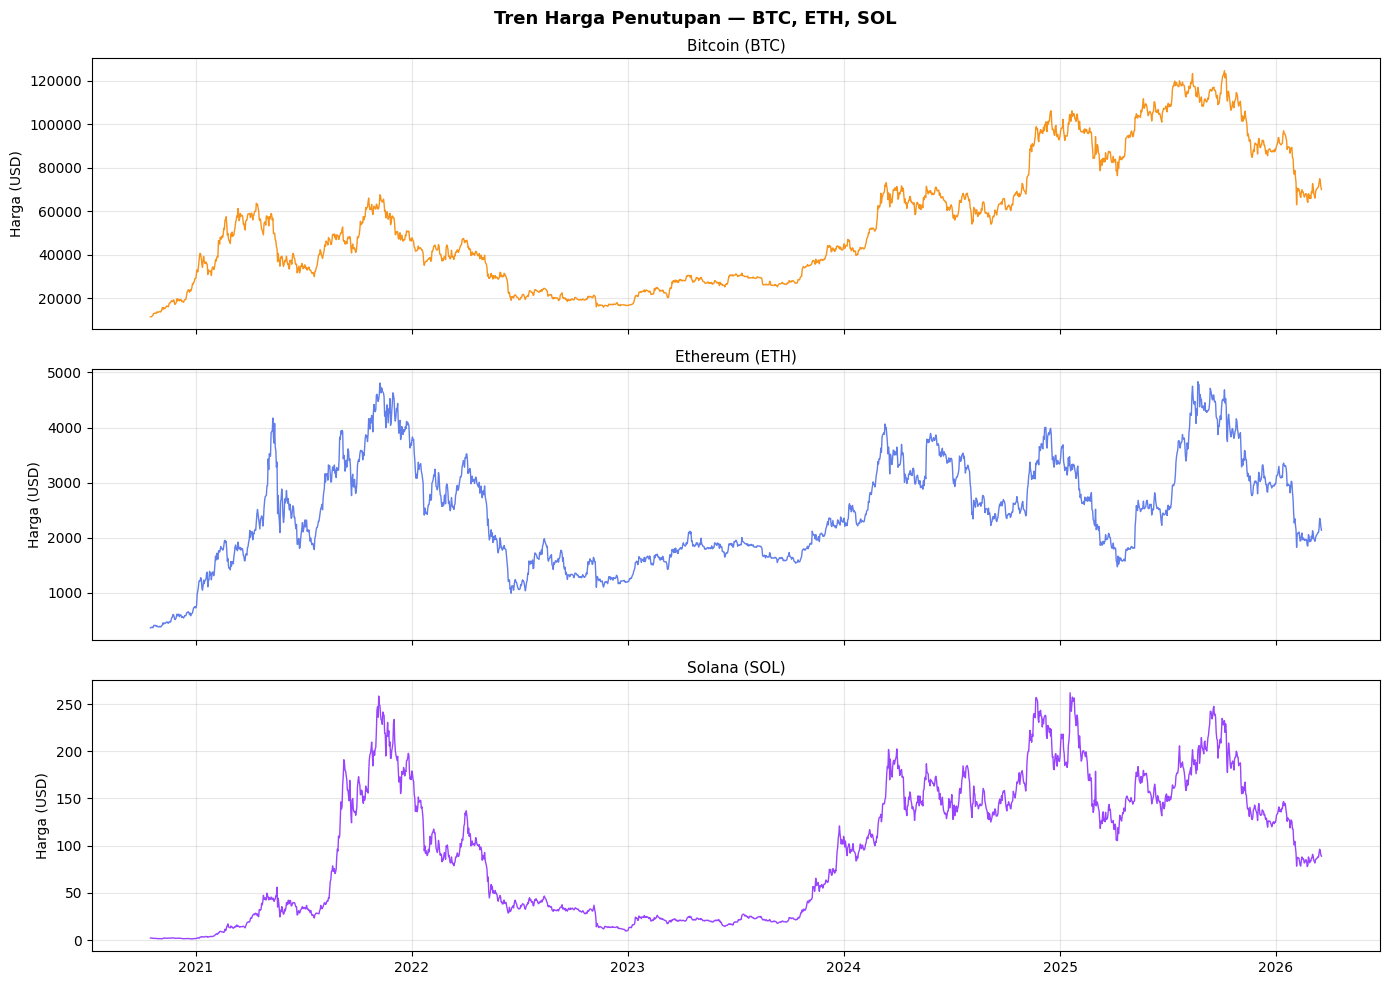

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (name, df, color) in zip(axes, [
    ('Bitcoin (BTC)', btc_raw, '#F7931A'),
    ('Ethereum (ETH)', eth_raw, '#627EEA'),
    ('Solana (SOL)',   sol_raw, '#9945FF')
]):
    ax.plot(df['Date'], df['price_close'], color=color, linewidth=1)
    ax.set_ylabel('Harga (USD)', fontsize=10)
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=0.3)
plt.suptitle('Tren Harga Penutupan — BTC, ETH, SOL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_harga.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b. Korelasi Spearman

In [7]:
features_for_corr = SENTIMENT_COLS + ONCHAIN_COLS
results_corr = {}
for name, df in [('BTC', btc_raw), ('ETH', eth_raw), ('SOL', sol_raw)]:
    corr_vals = {}
    for feat in features_for_corr:
        if feat in df.columns:
            corr, _ = spearmanr(df[feat].fillna(0), df[TARGET_COL])
            corr_vals[feat] = round(corr, 4)
    results_corr[name] = corr_vals

corr_df = pd.DataFrame(results_corr)
print("=== Korelasi Spearman vs price_close ===")
print(corr_df.to_string())

=== Korelasi Spearman vs price_close ===
                         BTC     ETH     SOL
sentiment_positive   -0.4892 -0.2113  0.4596
sentiment_negative   -0.1219 -0.0566  0.4829
social_dominance      0.1790 -0.1464  0.7574
fear_greed            0.2079  0.1444  0.0830
active_addresses     -0.6038  0.5616  0.7000
whale_stablecoin_pct  0.4556  0.5548  0.4552
transaction_volume   -0.5788  0.0457  0.6610
network_growth       -0.6464  0.4727  0.8180
dev_activity         -0.0884 -0.3601 -0.1050


### 5c. Plot heatmap korelasi

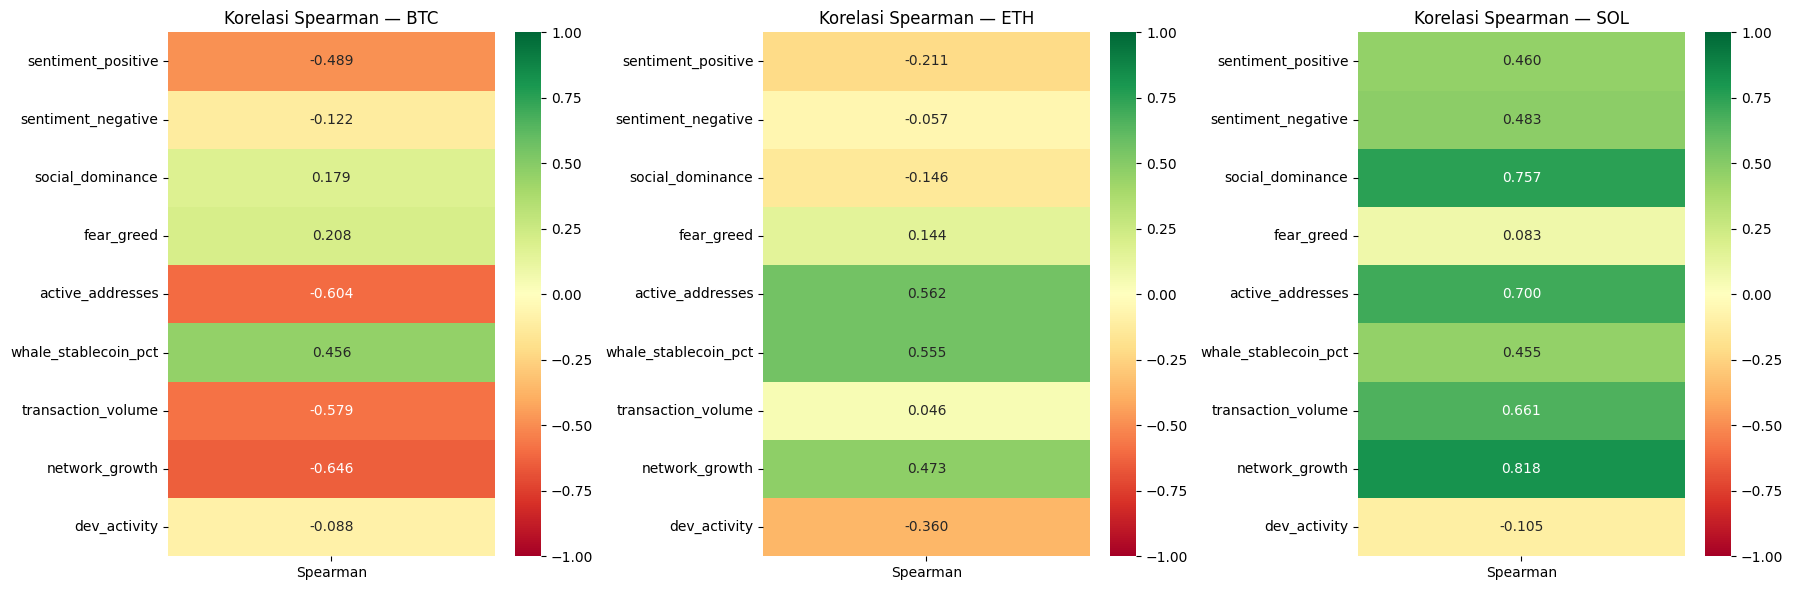

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, coin in zip(axes, ['BTC', 'ETH', 'SOL']):
    data = pd.DataFrame.from_dict(results_corr[coin], orient='index',
                                   columns=['Spearman'])
    sns.heatmap(data, annot=True, fmt='.3f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Korelasi Spearman — {coin}')
plt.tight_layout()
plt.savefig('plot_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

### 5d. Drop dev_activity berdasarkan korelasi

In [9]:
ONCHAIN_COLS.remove('dev_activity')
for df in [btc_raw, eth_raw, sol_raw]:
    df.drop(columns=['dev_activity'], inplace=True)
print("\ndev_activity di-drop. ONCHAIN_COLS final:", ONCHAIN_COLS)


dev_activity di-drop. ONCHAIN_COLS final: ['active_addresses', 'whale_stablecoin_pct', 'transaction_volume', 'network_growth']


### 5e. Skewness check

In [10]:
all_features = PRICE_COLS + SENTIMENT_COLS + ONCHAIN_COLS
print(f"\n{'Fitur':<25} {'BTC':>8} {'ETH':>8} {'SOL':>8}")
print("-" * 55)
for feat in all_features:
    b = skew(btc_raw[feat].dropna()) if feat in btc_raw.columns else 0
    e = skew(eth_raw[feat].dropna()) if feat in eth_raw.columns else 0
    s = skew(sol_raw[feat].dropna()) if feat in sol_raw.columns else 0
    print(f"{feat:<25} {b:>8.3f} {e:>8.3f} {s:>8.3f}")


Fitur                          BTC      ETH      SOL
-------------------------------------------------------
price_open                   0.638    0.215    0.315
price_high                   0.620    0.209    0.313
price_low                    0.660    0.220    0.318
price_close                  0.637    0.218    0.315
price_volume                 2.983    2.599    3.048
sentiment_positive           1.951    1.534    3.513
sentiment_negative           2.747    1.665    2.681
social_dominance             0.110    0.305    1.112
fear_greed                  -0.026   -0.026   -0.026
active_addresses             0.280    2.463    1.330
whale_stablecoin_pct        -1.823   -1.823   -1.823
transaction_volume           3.045    2.128    5.842
network_growth               0.291    2.683    1.763


### 5f. Plot distribusi BTC sebagai representatif

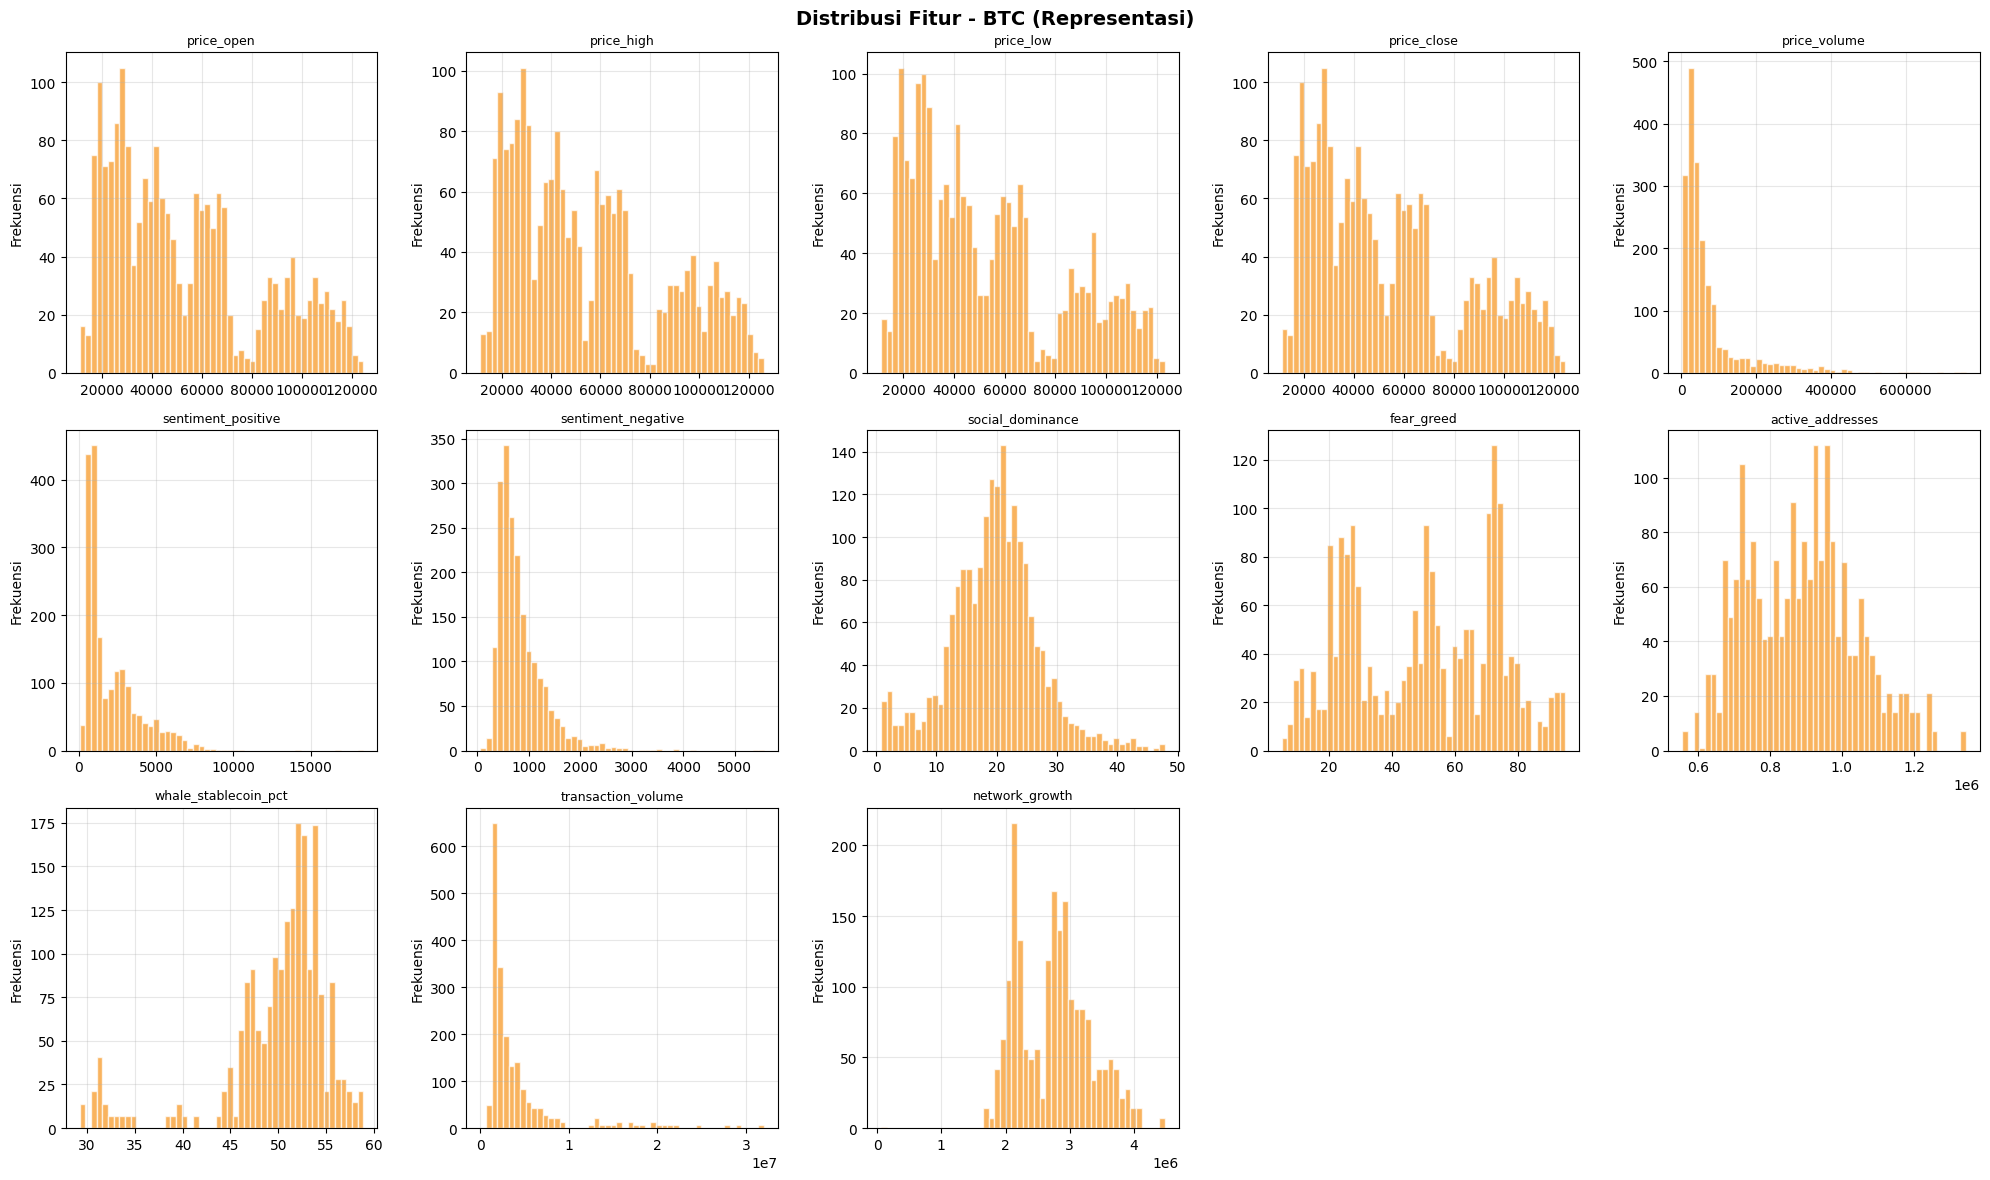

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, feat in enumerate(all_features):
    axes[i].hist(btc_raw[feat], bins=50, color='#F7931A', 
                 alpha=0.7, edgecolor='white')
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('Frekuensi')
    axes[i].grid(True, alpha=0.3)
for j in range(len(all_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribusi Fitur - BTC (Representasi)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distribusi_btc.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# === Inspeksi Kualitas Data Sentimen SOL ===
# Dilakukan pada dataset efektif (16 Okt 2020 – 19 Mar 2026)

print("=== Kualitas Data Sentimen pada Dataset Efektif ===")
print()
for name, df in [('BTC', btc_raw), ('ETH', eth_raw), ('SOL', sol_raw)]:
    print(f"--- {name} ({len(df)} baris) ---")
    for col in ['sentiment_positive', 'sentiment_negative']:
        zeros   = (df[col] == 0).sum()
        Q1      = df[col].quantile(0.25)
        Q3      = df[col].quantile(0.75)
        IQR     = Q3 - Q1
        outlier = ((df[col] < Q1 - 1.5*IQR) |
                   (df[col] > Q3 + 1.5*IQR)).sum()
        pct     = outlier / len(df) * 100
        print(f"  {col}: zeros={zeros}, "
              f"outlier={outlier} ({pct:.1f}%)")
    print()

=== Kualitas Data Sentimen pada Dataset Efektif ===

--- BTC (1980 baris) ---
  sentiment_positive: zeros=0, outlier=78 (3.9%)
  sentiment_negative: zeros=0, outlier=91 (4.6%)

--- ETH (1980 baris) ---
  sentiment_positive: zeros=0, outlier=56 (2.8%)
  sentiment_negative: zeros=0, outlier=91 (4.6%)

--- SOL (1980 baris) ---
  sentiment_positive: zeros=0, outlier=141 (7.1%)
  sentiment_negative: zeros=0, outlier=161 (8.1%)



## 6. Preprocessing

In [55]:
def preprocess_fixed(df_raw, price_cols, sentiment_cols, onchain_cols,
                     target_col, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    df = df_raw.copy().reset_index(drop=True)
    
    # Log Transform fitur skewed
    for col in SKEWED_COLS:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    
    # Split dulu sebelum fit scaler
    n = len(df)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))
    
    df_train = df.iloc[:train_end].copy()
    df_val   = df.iloc[train_end:val_end].copy()
    df_test  = df.iloc[val_end:].copy()
    
    # Fit scaler hanya pada training set
    scaler_target    = MinMaxScaler()
    scaler_price     = MinMaxScaler()
    scaler_sentiment = MinMaxScaler()
    scaler_onchain   = MinMaxScaler()
    
    price_cols_no_target = [c for c in price_cols if c != target_col]
    
    scaler_target.fit(df_train[[target_col]])
    scaler_price.fit(df_train[price_cols_no_target])
    scaler_sentiment.fit(df_train[sentiment_cols])
    scaler_onchain.fit(df_train[onchain_cols])
    
    # Transform semua split
    for df_split in [df_train, df_val, df_test]:
        df_split[price_cols_no_target] = scaler_price.transform(
            df_split[price_cols_no_target])
        df_split[sentiment_cols]       = scaler_sentiment.transform(
            df_split[sentiment_cols])
        df_split[onchain_cols]         = scaler_onchain.transform(
            df_split[onchain_cols])
        df_split[[target_col]]         = scaler_target.transform(
            df_split[[target_col]])
    
    scalers = {
        'price':     scaler_price,
        'sentiment': scaler_sentiment,
        'onchain':   scaler_onchain,
        'target':    scaler_target
    }
    
    return df_train, df_val, df_test, scalers

print("Fungsi preprocessing berhasil di-init.")

Fungsi preprocessing berhasil di-init.


## 7. Windowing Function

In [13]:

def create_sequences_from_split(df_train, df_val, df_test,
                                price_cols, sentiment_cols,
                                onchain_cols, target_col, T):
    def make_sequences(df):
        Xp, Xs, Xo, y = [], [], [], []
        for i in range(T, len(df)):
            Xp.append(df[price_cols].iloc[i-T:i].values)
            Xs.append(df[sentiment_cols].iloc[i-T:i].values)
            Xo.append(df[onchain_cols].iloc[i-T:i].values)
            y.append(df[target_col].iloc[i])
        return (np.array(Xp), np.array(Xs),
                np.array(Xo), np.array(y))

    return (make_sequences(df_train),
            make_sequences(df_val),
            make_sequences(df_test))

print("create_sequences_from_split didefinisikan.")

create_sequences_from_split didefinisikan.


## 8. Definisi 8 Model

In [14]:
# === LSTM VARIANTS ===
def build_lstm_price(T, n_price, n_sentiment, n_onchain):
    inp = Input(shape=(T, n_price), name='input_price')
    x = LSTM(64, return_sequences=False)(inp)
    x = Dropout(0.2)(x)
    out = Dense(1, name='output')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

def build_lstm_sentiment(T, n_price, n_sentiment, n_onchain):
    inp_p = Input(shape=(T, n_price), name='input_price')
    x1 = LSTM(64, return_sequences=False)(inp_p)
    x1 = Dropout(0.2)(x1)

    inp_s = Input(shape=(T, n_sentiment), name='input_sentiment')
    x2 = LSTM(32, return_sequences=True)(inp_s)
    x2 = Dropout(0.2)(x2)
    x2 = LSTM(16)(x2)
    x2 = Dropout(0.2)(x2)

    merged = Concatenate()([x1, x2])
    out = Dense(32, activation='relu')(merged)
    out = Dropout(0.2)(out)
    out = Dense(1, name='output')(out)
    model = Model(inputs=[inp_p, inp_s], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

def build_lstm_onchain(T, n_price, n_sentiment, n_onchain):
    inp_p = Input(shape=(T, n_price), name='input_price')
    x1 = LSTM(64, return_sequences=False)(inp_p)
    x1 = Dropout(0.2)(x1)

    inp_o = Input(shape=(T, n_onchain), name='input_onchain')
    x3 = Flatten()(inp_o)
    x3 = Dense(32, activation='relu')(x3)
    x3 = Dropout(0.2)(x3)
    x3 = Dense(16, activation='relu')(x3)

    merged = Concatenate()([x1, x3])
    out = Dense(32, activation='relu')(merged)
    out = Dropout(0.2)(out)
    out = Dense(1, name='output')(out)
    model = Model(inputs=[inp_p, inp_o], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

def build_lstm_full(T, n_price, n_sentiment, n_onchain):
    inp_p = Input(shape=(T, n_price), name='input_price')
    x1 = LSTM(64, return_sequences=False)(inp_p)
    x1 = Dropout(0.2)(x1)

    inp_s = Input(shape=(T, n_sentiment), name='input_sentiment')
    x2 = LSTM(32, return_sequences=True)(inp_s)
    x2 = Dropout(0.2)(x2)
    x2 = LSTM(16)(x2)
    x2 = Dropout(0.2)(x2)

    inp_o = Input(shape=(T, n_onchain), name='input_onchain')
    x3 = Flatten()(inp_o)
    x3 = Dense(32, activation='relu')(x3)
    x3 = Dropout(0.2)(x3)
    x3 = Dense(16, activation='relu')(x3)

    merged = Concatenate()([x1, x2, x3])
    out = Dense(32, activation='relu')(merged)
    out = Dropout(0.2)(out)
    out = Dense(1, name='output')(out)
    model = Model(inputs=[inp_p, inp_s, inp_o], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

# === GRU VARIANTS ===
def build_gru_price(T, n_price, n_sentiment, n_onchain):
    inp = Input(shape=(T, n_price), name='input_price')
    x = GRU(64, return_sequences=False)(inp)
    x = Dropout(0.2)(x)
    out = Dense(1, name='output')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

def build_gru_sentiment(T, n_price, n_sentiment, n_onchain):
    inp_p = Input(shape=(T, n_price), name='input_price')
    x1 = GRU(64, return_sequences=False)(inp_p)
    x1 = Dropout(0.2)(x1)

    inp_s = Input(shape=(T, n_sentiment), name='input_sentiment')
    x2 = LSTM(32, return_sequences=True)(inp_s)
    x2 = Dropout(0.2)(x2)
    x2 = LSTM(16)(x2)
    x2 = Dropout(0.2)(x2)

    merged = Concatenate()([x1, x2])
    out = Dense(32, activation='relu')(merged)
    out = Dropout(0.2)(out)
    out = Dense(1, name='output')(out)
    model = Model(inputs=[inp_p, inp_s], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

def build_gru_onchain(T, n_price, n_sentiment, n_onchain):
    inp_p = Input(shape=(T, n_price), name='input_price')
    x1 = GRU(64, return_sequences=False)(inp_p)
    x1 = Dropout(0.2)(x1)

    inp_o = Input(shape=(T, n_onchain), name='input_onchain')
    x3 = Flatten()(inp_o)
    x3 = Dense(32, activation='relu')(x3)
    x3 = Dropout(0.2)(x3)
    x3 = Dense(16, activation='relu')(x3)

    merged = Concatenate()([x1, x3])
    out = Dense(32, activation='relu')(merged)
    out = Dropout(0.2)(out)
    out = Dense(1, name='output')(out)
    model = Model(inputs=[inp_p, inp_o], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

def build_gru_full(T, n_price, n_sentiment, n_onchain):
    inp_p = Input(shape=(T, n_price), name='input_price')
    x1 = GRU(64, return_sequences=False)(inp_p)
    x1 = Dropout(0.2)(x1)

    inp_s = Input(shape=(T, n_sentiment), name='input_sentiment')
    x2 = LSTM(32, return_sequences=True)(inp_s)
    x2 = Dropout(0.2)(x2)
    x2 = LSTM(16)(x2)
    x2 = Dropout(0.2)(x2)

    inp_o = Input(shape=(T, n_onchain), name='input_onchain')
    x3 = Flatten()(inp_o)
    x3 = Dense(32, activation='relu')(x3)
    x3 = Dropout(0.2)(x3)
    x3 = Dense(16, activation='relu')(x3)

    merged = Concatenate()([x1, x2, x3])
    out = Dense(32, activation='relu')(merged)
    out = Dropout(0.2)(out)
    out = Dense(1, name='output')(out)
    model = Model(inputs=[inp_p, inp_s, inp_o], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

# Registry model
MODEL_BUILDERS = {
    'LSTM-Price':     build_lstm_price,
    'LSTM-Sentiment': build_lstm_sentiment,
    'LSTM-OnChain':   build_lstm_onchain,
    'LSTM-Full':      build_lstm_full,
    'GRU-Price':      build_gru_price,
    'GRU-Sentiment':  build_gru_sentiment,
    'GRU-OnChain':    build_gru_onchain,
    'GRU-Full':       build_gru_full,
}

MODEL_INPUTS_TRAIN = {
    'LSTM-Price':     lambda xp, xs, xo: [xp],
    'LSTM-Sentiment': lambda xp, xs, xo: [xp, xs],
    'LSTM-OnChain':   lambda xp, xs, xo: [xp, xo],
    'LSTM-Full':      lambda xp, xs, xo: [xp, xs, xo],
    'GRU-Price':      lambda xp, xs, xo: [xp],
    'GRU-Sentiment':  lambda xp, xs, xo: [xp, xs],
    'GRU-OnChain':    lambda xp, xs, xo: [xp, xo],
    'GRU-Full':       lambda xp, xs, xo: [xp, xs, xo],
}

print("8 model berhasil didefinisikan:")
for name in MODEL_BUILDERS:
    print(f"  - {name}")

8 model berhasil didefinisikan:
  - LSTM-Price
  - LSTM-Sentiment
  - LSTM-OnChain
  - LSTM-Full
  - GRU-Price
  - GRU-Sentiment
  - GRU-OnChain
  - GRU-Full


## 9. Fungsi Eksperimen

In [15]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=ES_PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=10, min_lr=1e-7, verbose=0)
    ]

def evaluate_model(model, inputs_test, y_te, target_scaler):
    y_pred = model.predict(inputs_test, verbose=0)
    y_actual  = target_scaler.inverse_transform(
        y_te.reshape(-1, 1)).flatten()
    y_pred_inv = target_scaler.inverse_transform(y_pred).flatten()
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred_inv))
    mae  = mean_absolute_error(y_actual, y_pred_inv)
    mape = np.mean(np.abs((y_actual - y_pred_inv) / y_actual)) * 100
    r2   = r2_score(y_actual, y_pred_inv)
    return rmse, mae, mape, r2, y_actual, y_pred_inv

def run_full_experiment(df_raw, price_cols, sentiment_cols, onchain_cols,
                        target_col, T, seed=42):
    df_train, df_val, df_test, scalers = preprocess_fixed(
        df_raw, price_cols, sentiment_cols, onchain_cols, target_col
    )
    train, val, test = create_sequences_from_split(
        df_train, df_val, df_test,
        price_cols, sentiment_cols, onchain_cols, target_col, T
    )
    Xp_tr, Xs_tr, Xo_tr, y_tr = train
    Xp_vl, Xs_vl, Xo_vl, y_vl = val
    Xp_te, Xs_te, Xo_te, y_te  = test

    n_price     = len(price_cols)
    n_sentiment = len(sentiment_cols)
    n_onchain   = len(onchain_cols)

    tf.random.set_seed(seed)
    np.random.seed(seed)

    results = {}
    for model_name, builder in MODEL_BUILDERS.items():
        model = builder(T, n_price, n_sentiment, n_onchain)

        inputs_train = MODEL_INPUTS_TRAIN[model_name](Xp_tr, Xs_tr, Xo_tr)
        inputs_val   = MODEL_INPUTS_TRAIN[model_name](Xp_vl, Xs_vl, Xo_vl)
        inputs_test  = MODEL_INPUTS_TRAIN[model_name](Xp_te, Xs_te, Xo_te)

        history = model.fit(
            inputs_train, y_tr,
            validation_data=(inputs_val, y_vl),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=get_callbacks(), verbose=0
        )

        actual_epochs = len(history.history['loss'])
        final_lr      = float(history.history['learning_rate'][-1])

        rmse, mae, mape, r2, y_actual, y_pred = evaluate_model(
            model, inputs_test, y_te, scalers['target']
        )

        results[model_name] = {
            'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2,
            'y_actual': y_actual, 'y_pred': y_pred,
            'model': model, 'scalers': scalers,
            'epochs': actual_epochs, 'final_lr': final_lr
        }

    return results

print("Fungsi eksperimen berhasil didefinisikan.")

Fungsi eksperimen berhasil didefinisikan.


## 10. Window Search (BTC sebagai proxy)

In [23]:
# Evaluasi T=7, 14, 30 menggunakan LSTM-Full dan GRU-Full

print("=== Window Search BTC ===")
print("Kandidat T:  7, 14, 21, 30, 45, 60")
print("Model proxy: LSTM-Full dan GRU-Full")
print("Runs per kandidat: 5\n")

window_results = []

for T_val in [7, 14, 21, 30, 45, 60]:
    for model_name in ['LSTM-Full', 'GRU-Full']:
        run_rmse = []
        for run in range(1, N_RUNS + 1):
            df_train, df_val, df_test, scalers_ws = preprocess_fixed(
                btc_raw, PRICE_COLS, SENTIMENT_COLS, ONCHAIN_COLS, TARGET_COL
            )
            train, val, test = create_sequences_from_split(
                df_train, df_val, df_test,
                PRICE_COLS, SENTIMENT_COLS, ONCHAIN_COLS, TARGET_COL, T_val
            )
            Xp_tr, Xs_tr, Xo_tr, y_tr = train
            Xp_vl, Xs_vl, Xo_vl, y_vl = val
            Xp_te, Xs_te, Xo_te, y_te  = test

            tf.random.set_seed(run * 10)
            np.random.seed(run * 10)

            model = MODEL_BUILDERS[model_name](
                T_val, len(PRICE_COLS),
                len(SENTIMENT_COLS), len(ONCHAIN_COLS)
            )
            inputs_train = MODEL_INPUTS_TRAIN[model_name](Xp_tr, Xs_tr, Xo_tr)
            inputs_val   = MODEL_INPUTS_TRAIN[model_name](Xp_vl, Xs_vl, Xo_vl)
            inputs_test  = MODEL_INPUTS_TRAIN[model_name](Xp_te, Xs_te, Xo_te)

            model.fit(
                inputs_train, y_tr,
                validation_data=(inputs_val, y_vl),
                epochs=EPOCHS, batch_size=BATCH_SIZE,
                callbacks=get_callbacks(), verbose=0
            )

            rmse, _, _, _, _, _ = evaluate_model(
                model, inputs_test, y_te, scalers_ws['target']
            )
            run_rmse.append(rmse)

        avg_rmse = np.mean(run_rmse)
        window_results.append({
            'T': T_val, 'model': model_name, 'RMSE': avg_rmse
        })
        print(f"T={T_val:2d} | {model_name:<16} → RMSE={avg_rmse:,.2f}")

# Pilih T terbaik berdasarkan rata-rata RMSE semua model
ws_df = pd.DataFrame(window_results)
best_T_per_model = ws_df.loc[ws_df.groupby('model')['RMSE'].idxmin()]
print("\n=== T Terbaik per Model ===")
print(best_T_per_model[['model', 'T', 'RMSE']].to_string(index=False))

# Pilih T final berdasarkan rata-rata semua model
avg_per_T = ws_df.groupby('T')['RMSE'].mean()
best_T = int(avg_per_T.idxmin())
print(f"\nRata-rata RMSE per T:")
print(avg_per_T.round(2).to_string())
print(f"\nT final ditetapkan: T={14}")
T = 14

=== Window Search BTC ===
Kandidat T:  7, 14, 21, 30, 45, 60
Model proxy: LSTM-Full dan GRU-Full
Runs per kandidat: 5

T= 7 | LSTM-Full        → RMSE=3,266.28
T= 7 | GRU-Full         → RMSE=2,633.48
T=14 | LSTM-Full        → RMSE=3,317.41
T=14 | GRU-Full         → RMSE=2,625.88
T=21 | LSTM-Full        → RMSE=3,502.76
T=21 | GRU-Full         → RMSE=2,695.84
T=30 | LSTM-Full        → RMSE=3,542.01
T=30 | GRU-Full         → RMSE=2,787.43
T=45 | LSTM-Full        → RMSE=2,969.44
T=45 | GRU-Full         → RMSE=2,546.14
T=60 | LSTM-Full        → RMSE=3,074.18
T=60 | GRU-Full         → RMSE=2,635.67

=== T Terbaik per Model ===
    model  T        RMSE
 GRU-Full 45 2546.140578
LSTM-Full 45 2969.440729

Rata-rata RMSE per T:
T
7     2949.88
14    2971.65
21    3099.30
30    3164.72
45    2757.79
60    2854.92

T final ditetapkan: T=45


## 11. Eksperimen Utama

In [27]:
# 8 model × 3 koin × 5 run = 120 training run

print("=== Eksperimen Utama ===")
print(f"T={T}, {N_RUNS} run per model per koin")
print(f"Total training: {8 * 3 * N_RUNS} run\n")

COINS = {
    'BTC': btc_raw,
    'ETH': eth_raw,
    'SOL': sol_raw
}

all_runs      = []
final_results = {}

for coin, df_raw in COINS.items():
    print(f"\n=== {coin} ===")
    final_results[coin] = {}
    coin_runs = []

    df_train, df_val, df_test, scalers = preprocess_fixed(
        df_raw, PRICE_COLS, SENTIMENT_COLS, ONCHAIN_COLS, TARGET_COL
    )
    train, val, test = create_sequences_from_split(
        df_train, df_val, df_test,
        PRICE_COLS, SENTIMENT_COLS, ONCHAIN_COLS, TARGET_COL, T
    )

    Xp_tr, Xs_tr, Xo_tr, y_tr = train
    Xp_vl, Xs_vl, Xo_vl, y_vl = val
    Xp_te, Xs_te, Xo_te, y_te  = test

    for run in range(1, N_RUNS + 1):
        print(f"  Run {run}/{N_RUNS}...")

        for model_name, builder in MODEL_BUILDERS.items():
            tf.random.set_seed(run * 10)
            np.random.seed(run * 10)

            model = builder(T, len(PRICE_COLS),
                           len(SENTIMENT_COLS), len(ONCHAIN_COLS))

            inputs_train = MODEL_INPUTS_TRAIN[model_name](Xp_tr, Xs_tr, Xo_tr)
            inputs_val   = MODEL_INPUTS_TRAIN[model_name](Xp_vl, Xs_vl, Xo_vl)
            inputs_test  = MODEL_INPUTS_TRAIN[model_name](Xp_te, Xs_te, Xo_te)

            history = model.fit(
                inputs_train, y_tr,
                validation_data=(inputs_val, y_vl),
                epochs=EPOCHS, batch_size=BATCH_SIZE,
                callbacks=get_callbacks(), verbose=0
            )

            actual_epochs = len(history.history['loss'])
            final_lr      = float(history.history['learning_rate'][-1])

            rmse, mae, mape, r2, y_actual, y_pred = evaluate_model(
                model, inputs_test, y_te, scalers['target']
            )

            # Simpan semua run untuk analisis
            coin_runs.append({
                'coin': coin, 'run': run, 'model': model_name,
                'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2,
                'epochs': actual_epochs, 'final_lr': final_lr
            })

            # Simpan model dan prediksi dari run terakhir
            if run == N_RUNS:
                final_results[coin][model_name] = {
                    'model':    model,
                    'scalers':  scalers,
                    'y_actual': y_actual,
                    'y_pred':   y_pred
                }

    all_runs.extend(coin_runs)

    # Print rata-rata per koin
    coin_df = pd.DataFrame(coin_runs)
    avg = coin_df.groupby('model')[
        ['RMSE','MAE','MAPE','R2','epochs','final_lr']
    ].mean().round(4)
    avg = avg.reindex(MODEL_NAMES)
    print(f"\n  Rata-rata {coin}:")
    print(avg.to_string())

# Simpan semua run ke CSV
all_runs_df = pd.DataFrame(all_runs)
all_runs_df.to_csv('hasil_eksperimen_detail.csv', index=False)

summary = all_runs_df.groupby(['coin','model'])[
    ['RMSE','MAE','MAPE','R2','epochs','final_lr']
].mean().round(4)
summary.to_csv('hasil_eksperimen_summary.csv')

print("\n=== Eksperimen selesai ===")
print("Tersimpan:")
print("  - hasil_eksperimen_detail.csv  (semua run)")
print("  - hasil_eksperimen_summary.csv (rata-rata)")

=== Eksperimen Utama ===
T=14, 5 run per model per koin
Total training: 120 run


=== BTC ===
  Run 1/5...
  Run 2/5...
  Run 3/5...
  Run 4/5...
  Run 5/5...

  Rata-rata BTC:
                     RMSE        MAE    MAPE      R2  epochs  final_lr
model                                                                 
LSTM-Price      3192.4365  2439.8589  2.7052  0.9626   100.4    0.0000
LSTM-Sentiment  3500.4395  2648.4188  2.9519  0.9546    46.8    0.0001
LSTM-OnChain    3362.0338  2534.4500  2.8352  0.9585    60.4    0.0000
LSTM-Full       3647.4283  2766.3187  3.0881  0.9507    44.6    0.0001
GRU-Price       2610.8921  1940.5696  2.1933  0.9750    87.0    0.0000
GRU-Sentiment   2652.3858  2036.7827  2.2963  0.9742    57.4    0.0001
GRU-OnChain     2838.9351  2164.2994  2.4449  0.9704    57.0    0.0001
GRU-Full        2661.9398  2049.4955  2.2994  0.9740    58.0    0.0000

=== ETH ===
  Run 1/5...
  Run 2/5...
  Run 3/5...
  Run 4/5...
  Run 5/5...

  Rata-rata ETH:
                 

## 12. Tabel Perbandingan Hasil

In [28]:
print("=== Tabel Perbandingan Hasil (Rata-rata 3 Run) ===\n")

summary_df = pd.DataFrame(all_runs)

for coin in ['BTC', 'ETH', 'SOL']:
    coin_data = summary_df[summary_df['coin'] == coin]
    avg = coin_data.groupby('model')[
        ['RMSE','MAE','MAPE','R2']
    ].mean().round(4)
    avg = avg.reindex(MODEL_NAMES)
    print(f"--- {coin} ---")
    print(avg.to_string())
    print()

# Tabel lengkap dengan epochs dan final_lr
print("=== Detail Lengkap (termasuk Epochs dan LR) ===\n")
for coin in ['BTC', 'ETH', 'SOL']:
    coin_data = summary_df[summary_df['coin'] == coin]
    avg = coin_data.groupby('model')[
        ['RMSE','MAE','MAPE','R2','epochs','final_lr']
    ].mean().round(4)
    avg = avg.reindex(MODEL_NAMES)
    print(f"--- {coin} ---")
    print(avg.to_string())
    print()

# Identifikasi model terbaik per koin berdasarkan R²
print("=== Model Terbaik per Koin (berdasarkan R²) ===\n")
for coin in ['BTC', 'ETH', 'SOL']:
    coin_data = summary_df[summary_df['coin'] == coin]
    avg = coin_data.groupby('model')['R2'].mean()
    best_model = avg.idxmax()
    best_r2    = avg.max()
    print(f"{coin}: {best_model} (R²={best_r2:.4f})")

=== Tabel Perbandingan Hasil (Rata-rata 3 Run) ===

--- BTC ---
                     RMSE        MAE    MAPE      R2
model                                               
LSTM-Price      3192.4365  2439.8589  2.7052  0.9626
LSTM-Sentiment  3500.4395  2648.4188  2.9519  0.9546
LSTM-OnChain    3362.0338  2534.4500  2.8352  0.9585
LSTM-Full       3647.4283  2766.3187  3.0881  0.9507
GRU-Price       2610.8921  1940.5696  2.1933  0.9750
GRU-Sentiment   2652.3858  2036.7827  2.2963  0.9742
GRU-OnChain     2838.9351  2164.2994  2.4449  0.9704
GRU-Full        2661.9398  2049.4955  2.2994  0.9740

--- ETH ---
                    RMSE       MAE    MAPE      R2
model                                             
LSTM-Price      142.5681  107.5328  3.5875  0.9661
LSTM-Sentiment  173.3166  133.5083  4.4857  0.9486
LSTM-OnChain    165.0367  129.7555  4.5358  0.9544
LSTM-Full       171.6464  132.5359  4.5754  0.9503
GRU-Price       130.3449   95.7204  3.1989  0.9717
GRU-Sentiment   138.0408  103.7028  

In [40]:
# Statistik Konvergensi Pelatihan — Median, Min, Max Epochs dan Reduksi LR

import numpy as np
import pandas as pd

detail = pd.read_csv('hasil_eksperimen_detail.csv')

MODEL_ORDER = [
    'LSTM-Price', 'LSTM-Sentiment', 'LSTM-OnChain', 'LSTM-Full',
    'GRU-Price',  'GRU-Sentiment',  'GRU-OnChain',  'GRU-Full'
]

def count_lr_reductions(lr, lr_init=0.0005):
    if lr <= 0 or pd.isna(lr):
        return 0
    n = round(np.log2(lr_init / lr))
    return max(0, n)

detail['lr_reductions'] = detail['final_lr'].apply(count_lr_reductions)

rows = []
for coin in ['BTC', 'ETH', 'SOL']:
    for model in MODEL_ORDER:
        sub = detail[(detail['coin'] == coin) & (detail['model'] == model)]
        epochs_med = sub['epochs'].median()
        epochs_min = sub['epochs'].min()
        epochs_max = sub['epochs'].max()
        lr_red_med = sub['lr_reductions'].median()
        lr_red_min = sub['lr_reductions'].min()
        lr_red_max = sub['lr_reductions'].max()
        rows.append({
            'coin':        coin,
            'model':       model,
            'epochs_med':  int(epochs_med),
            'epochs_min':  int(epochs_min),
            'epochs_max':  int(epochs_max),
            'lr_red_med':  int(lr_red_med),
            'lr_red_min':  int(lr_red_min),
            'lr_red_max':  int(lr_red_max),
        })

konvergensi_df = pd.DataFrame(rows)
konvergensi_df.to_csv('hasil_konvergensi.csv', index=False)

print(konvergensi_df.to_string(index=False))
print('\nTersimpan: hasil_konvergensi.csv')

coin          model  epochs_med  epochs_min  epochs_max  lr_red_med  lr_red_min  lr_red_max
 BTC     LSTM-Price          97          80         127           8           7          10
 BTC LSTM-Sentiment          46          29          64           4           2           4
 BTC   LSTM-OnChain          57          48          84           4           3           6
 BTC      LSTM-Full          42          31          64           3           2           5
 BTC      GRU-Price          82          65         133           6           4          12
 BTC  GRU-Sentiment          59          44          72           4           2           5
 BTC    GRU-OnChain          55          39          72           3           2           5
 BTC       GRU-Full          58          49          64           4           3           5
 ETH     LSTM-Price         102          92         140           6           6           9
 ETH LSTM-Sentiment          62          30          97           4           2 

## 13. Walk Forward Cross Validation (WFCV)

In [57]:
def walk_forward_cv(df_raw, price_cols, sentiment_cols, onchain_cols,
                    target_col, T, model_name, n_folds=5, seed=42):

    df = df_raw.copy().reset_index(drop=True)

    # Log transform
    for col in SKEWED_COLS:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

    n = len(df)
    # Minimal training = 50% data, test per fold = ~10%
    min_train = int(n * 0.5)
    fold_size = int(n * 0.1)

    fold_results = []

    for fold in range(n_folds):
        train_end = min_train + fold * fold_size
        test_end  = train_end + fold_size

        if test_end > n:
            break

        df_train_wf = df.iloc[:train_end].copy()
        df_test_wf  = df.iloc[train_end:test_end].copy()

        # Fit scaler pada training fold
        scaler_price_wf     = MinMaxScaler()
        scaler_sentiment_wf = MinMaxScaler()
        scaler_onchain_wf   = MinMaxScaler()
        scaler_target_wf    = MinMaxScaler()

        price_cols_no_target = [c for c in price_cols if c != target_col]

        scaler_price_wf.fit(df_train_wf[price_cols_no_target])
        scaler_sentiment_wf.fit(df_train_wf[sentiment_cols])
        scaler_onchain_wf.fit(df_train_wf[onchain_cols])
        scaler_target_wf.fit(df_train_wf[[target_col]])

        for df_split in [df_train_wf, df_test_wf]:
            df_split[price_cols_no_target] = scaler_price_wf.transform(
                df_split[price_cols_no_target])
            df_split[sentiment_cols]       = scaler_sentiment_wf.transform(
                df_split[sentiment_cols])
            df_split[onchain_cols]         = scaler_onchain_wf.transform(
                df_split[onchain_cols])
            df_split[[target_col]]         = scaler_target_wf.transform(
                df_split[[target_col]])

        # Buat sekuens
        def make_seq(df_seq):
            Xp, Xs, Xo, y = [], [], [], []
            for i in range(T, len(df_seq)):
                Xp.append(df_seq[price_cols].iloc[i-T:i].values)
                Xs.append(df_seq[sentiment_cols].iloc[i-T:i].values)
                Xo.append(df_seq[onchain_cols].iloc[i-T:i].values)
                y.append(df_seq[target_col].iloc[i])
            return (np.array(Xp), np.array(Xs),
                    np.array(Xo), np.array(y))

        Xp_tr, Xs_tr, Xo_tr, y_tr = make_seq(df_train_wf)
        Xp_te, Xs_te, Xo_te, y_te = make_seq(df_test_wf)

        if len(y_tr) < T or len(y_te) < T:
            continue

        # Val set = 10% terakhir dari training fold
        val_size = max(int(len(y_tr) * 0.1), T + 1)
        Xp_vl = Xp_tr[-val_size:]
        Xs_vl = Xs_tr[-val_size:]
        Xo_vl = Xo_tr[-val_size:]
        y_vl  = y_tr[-val_size:]
        Xp_tr = Xp_tr[:-val_size]
        Xs_tr = Xs_tr[:-val_size]
        Xo_tr = Xo_tr[:-val_size]
        y_tr  = y_tr[:-val_size]

        tf.random.set_seed(seed)
        np.random.seed(seed)

        model = MODEL_BUILDERS[model_name](
            T, len(price_cols), len(sentiment_cols), len(onchain_cols)
        )
        inputs_train = MODEL_INPUTS_TRAIN[model_name](Xp_tr, Xs_tr, Xo_tr)
        inputs_val   = MODEL_INPUTS_TRAIN[model_name](Xp_vl, Xs_vl, Xo_vl)
        inputs_test  = MODEL_INPUTS_TRAIN[model_name](Xp_te, Xs_te, Xo_te)

        model.fit(
            inputs_train, y_tr,
            validation_data=(inputs_val, y_vl),
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            callbacks=get_callbacks(), verbose=0
        )

        rmse, mae, mape, r2, _, _ = evaluate_model(
            model, inputs_test, y_te, scaler_target_wf
        )

        fold_results.append({
            'fold': fold + 1, 'model': model_name,
            'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2,
            'train_size': len(y_tr), 'test_size': len(y_te)
        })

        print(f"  Fold {fold+1}: RMSE={rmse:,.2f} | "
              f"MAPE={mape:.4f}% | R²={r2:.4f} "
              f"(train={len(y_tr)}, test={len(y_te)})")

    avg_rmse = np.mean([f['RMSE'] for f in fold_results])
    avg_mape = np.mean([f['MAPE'] for f in fold_results])
    avg_r2   = np.mean([f['R2']   for f in fold_results])
    print(f"  Rata-rata: RMSE={avg_rmse:,.2f} | "
          f"MAPE={avg_mape:.4f}% | R²={avg_r2:.4f}\n")

    return fold_results

# Jalankan WFCV untuk semua 8 model per koin
wfcv_results = []

for coin, df_raw_coin in COINS.items():
    print(f"\n=== WFCV {coin} ===")
    for model_name in MODEL_NAMES:
        print(f"--- WFCV {coin} — {model_name} ---")
        fold_res = walk_forward_cv(
            df_raw_coin, PRICE_COLS, SENTIMENT_COLS, ONCHAIN_COLS,
            TARGET_COL, T, model_name, n_folds=5
        )
        for r in fold_res:
            r['coin'] = coin
        wfcv_results.extend(fold_res)

wfcv_df = pd.DataFrame(wfcv_results)
wfcv_df.to_csv('hasil_wfcv.csv', index=False)
print("\nTersimpan: hasil_wfcv.csv")

# Perbandingan hold-out vs WFCV
summary_df_temp = pd.DataFrame(all_runs)
print("\n=== Perbandingan Hold-out vs WFCV ===")
print(f"{'Coin':<6} {'Model':<20} {'Hold-out R²':>12} {'WFCV R²':>10} {'Gap':>8}")
print("-" * 60)

for coin in ['BTC', 'ETH', 'SOL']:
    for model_name in MODEL_NAMES:
        holdout_r2 = summary_df_temp[
            (summary_df_temp['coin'] == coin) &
            (summary_df_temp['model'] == model_name)
        ]['R2'].mean()
        wfcv_r2 = np.mean([
            f['R2'] for f in wfcv_results
            if f['model'] == model_name and f['coin'] == coin
        ])
        gap = holdout_r2 - wfcv_r2
        print(f"{coin:<6} {model_name:<20} {holdout_r2:>12.4f} "
              f"{wfcv_r2:>10.4f} {gap:>8.4f}")


=== WFCV BTC ===
--- WFCV BTC — LSTM-Price ---
  Fold 1: RMSE=1,146.55 | MAPE=2.3245% | R²=0.9709 (train=879, test=184)
  Fold 2: RMSE=2,504.55 | MAPE=3.1125% | R²=0.8758 (train=1057, test=184)
  Fold 3: RMSE=2,549.89 | MAPE=2.4149% | R²=0.9791 (train=1235, test=184)
  Fold 4: RMSE=3,285.38 | MAPE=2.5005% | R²=0.9339 (train=1413, test=184)
  Fold 5: RMSE=3,380.20 | MAPE=2.8476% | R²=0.9581 (train=1592, test=184)
  Rata-rata: RMSE=2,573.31 | MAPE=2.6400% | R²=0.9436

--- WFCV BTC — LSTM-Sentiment ---
  Fold 1: RMSE=1,548.70 | MAPE=3.4230% | R²=0.9470 (train=879, test=184)
  Fold 2: RMSE=2,551.04 | MAPE=3.1249% | R²=0.8712 (train=1057, test=184)
  Fold 3: RMSE=3,373.25 | MAPE=3.1461% | R²=0.9634 (train=1235, test=184)
  Fold 4: RMSE=4,857.46 | MAPE=3.9768% | R²=0.8555 (train=1413, test=184)
  Fold 5: RMSE=3,718.10 | MAPE=3.1125% | R²=0.9493 (train=1592, test=184)
  Rata-rata: RMSE=3,209.71 | MAPE=3.3567% | R²=0.9173

--- WFCV BTC — LSTM-OnChain ---
  Fold 1: RMSE=1,594.57 | MAPE=4.0986%

## 14. Statistical Significance Test (Wilcoxon Signed-Rank)

In [59]:
# ── Wilcoxon Signed-Rank Test: GRU-Price vs semua model lain ─────────────────
# Input: R² dan MAPE per fold WFCV, pooled lintas 3 koin (N=15 per pasangan)
# Justifikasi: R² dan MAPE scale-independent, valid untuk pooling lintas aset

from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

wfcv_df  = pd.read_csv('hasil_wfcv.csv')
BASELINE = 'GRU-Price'
ALPHA    = 0.05

MODEL_ORDER = [
    'LSTM-Price', 'LSTM-Sentiment', 'LSTM-OnChain', 'LSTM-Full',
    'GRU-Sentiment', 'GRU-OnChain', 'GRU-Full'
]

print("=== Wilcoxon Signed-Rank Test ===")
print(f"Baseline : {BASELINE}")
print(f"Input    : R² dan MAPE per fold WFCV, pooled lintas 3 koin (N=15)")
print(f"Alpha    : {ALPHA}\n")

# Ambil nilai baseline (N=15: 5 fold × 3 koin, diurutkan coin → fold)
def get_values(model_name, metric):
    return wfcv_df[
        wfcv_df['model'] == model_name
    ].sort_values(['coin', 'fold'])[metric].values

r2_baseline   = get_values(BASELINE, 'R2')
mape_baseline = get_values(BASELINE, 'MAPE')

wilcoxon_results = []

for model_name in MODEL_ORDER:
    r2_model   = get_values(model_name, 'R2')
    mape_model = get_values(model_name, 'MAPE')

    if len(r2_baseline) != len(r2_model):
        print(f"SKIP {model_name}: N tidak sama")
        continue

    # Wilcoxon R² — GRU-Price lebih tinggi = lebih baik
    try:
        stat_r2, p_r2 = wilcoxon(
            r2_baseline, r2_model, alternative='two-sided')
    except Exception as e:
        p_r2, stat_r2 = float('nan'), float('nan')
        print(f"  ERROR R² {model_name}: {e}")

    # Wilcoxon MAPE — GRU-Price lebih rendah = lebih baik
    try:
        stat_mape, p_mape = wilcoxon(
            mape_baseline, mape_model, alternative='two-sided')
    except Exception as e:
        p_mape, stat_mape = float('nan'), float('nan')
        print(f"  ERROR MAPE {model_name}: {e}")

    sig_r2   = p_r2 < ALPHA
    sig_mape = p_mape < ALPHA

    mean_r2_base   = round(float(np.mean(r2_baseline)),   4)
    mean_r2_model  = round(float(np.mean(r2_model)),      4)
    mean_mp_base   = round(float(np.mean(mape_baseline)), 4)
    mean_mp_model  = round(float(np.mean(mape_model)),    4)
    delta_r2       = round(mean_r2_base  - mean_r2_model, 4)
    delta_mape     = round(mean_mp_model - mean_mp_base,  4)

    wilcoxon_results.append({
        'model1':            BASELINE,
        'model2':            model_name,
        'mean_R2_baseline':  mean_r2_base,
        'mean_R2_model':     mean_r2_model,
        'delta_R2':          delta_r2,
        'p_value_R2':        round(float(p_r2),   4),
        'significant_R2':    sig_r2,
        'mean_MAPE_baseline': mean_mp_base,
        'mean_MAPE_model':    mean_mp_model,
        'delta_MAPE':         delta_mape,
        'p_value_MAPE':       round(float(p_mape), 4),
        'significant_MAPE':   sig_mape,
    })

    print(f"{BASELINE} vs {model_name:<20}")
    print(f"  R²  : ΔR²={delta_r2:+.4f} | "
          f"p={p_r2:.4f} | "
          f"{'✅ Signifikan' if sig_r2 else '❌ Tidak Signifikan'}")
    print(f"  MAPE: ΔMAPE={delta_mape:+.4f}% | "
          f"p={p_mape:.4f} | "
          f"{'✅ Signifikan' if sig_mape else '❌ Tidak Signifikan'}")
    print()

wilcoxon_df = pd.DataFrame(wilcoxon_results)
wilcoxon_df.to_csv('hasil_wilcoxon.csv', index=False)

print("=" * 55)
print(f"Tersimpan: hasil_wilcoxon.csv")
print(f"\nRingkasan signifikansi:")
print(f"  R²  : {wilcoxon_df['significant_R2'].sum()} dari "
      f"{len(wilcoxon_df)} pasangan signifikan")
print(f"  MAPE: {wilcoxon_df['significant_MAPE'].sum()} dari "
      f"{len(wilcoxon_df)} pasangan signifikan")

=== Wilcoxon Signed-Rank Test ===
Baseline : GRU-Price
Input    : R² dan MAPE per fold WFCV, pooled lintas 3 koin (N=15)
Alpha    : 0.05

GRU-Price vs LSTM-Price          
  R²  : ΔR²=+0.0180 | p=0.0001 | ✅ Signifikan
  MAPE: ΔMAPE=+0.5163% | p=0.0001 | ✅ Signifikan

GRU-Price vs LSTM-Sentiment      
  R²  : ΔR²=+0.0367 | p=0.0001 | ✅ Signifikan
  MAPE: ΔMAPE=+1.0340% | p=0.0001 | ✅ Signifikan

GRU-Price vs LSTM-OnChain        
  R²  : ΔR²=+0.0649 | p=0.0001 | ✅ Signifikan
  MAPE: ΔMAPE=+1.6269% | p=0.0001 | ✅ Signifikan

GRU-Price vs LSTM-Full           
  R²  : ΔR²=+0.0743 | p=0.0001 | ✅ Signifikan
  MAPE: ΔMAPE=+1.9203% | p=0.0001 | ✅ Signifikan

GRU-Price vs GRU-Sentiment       
  R²  : ΔR²=+0.0135 | p=0.0009 | ✅ Signifikan
  MAPE: ΔMAPE=+0.4901% | p=0.0026 | ✅ Signifikan

GRU-Price vs GRU-OnChain         
  R²  : ΔR²=+0.0262 | p=0.0009 | ✅ Signifikan
  MAPE: ΔMAPE=+0.9145% | p=0.0012 | ✅ Signifikan

GRU-Price vs GRU-Full            
  R²  : ΔR²=+0.0196 | p=0.0020 | ✅ Signifikan
  

## 15. Visualisasi Prediksi vs Aktual

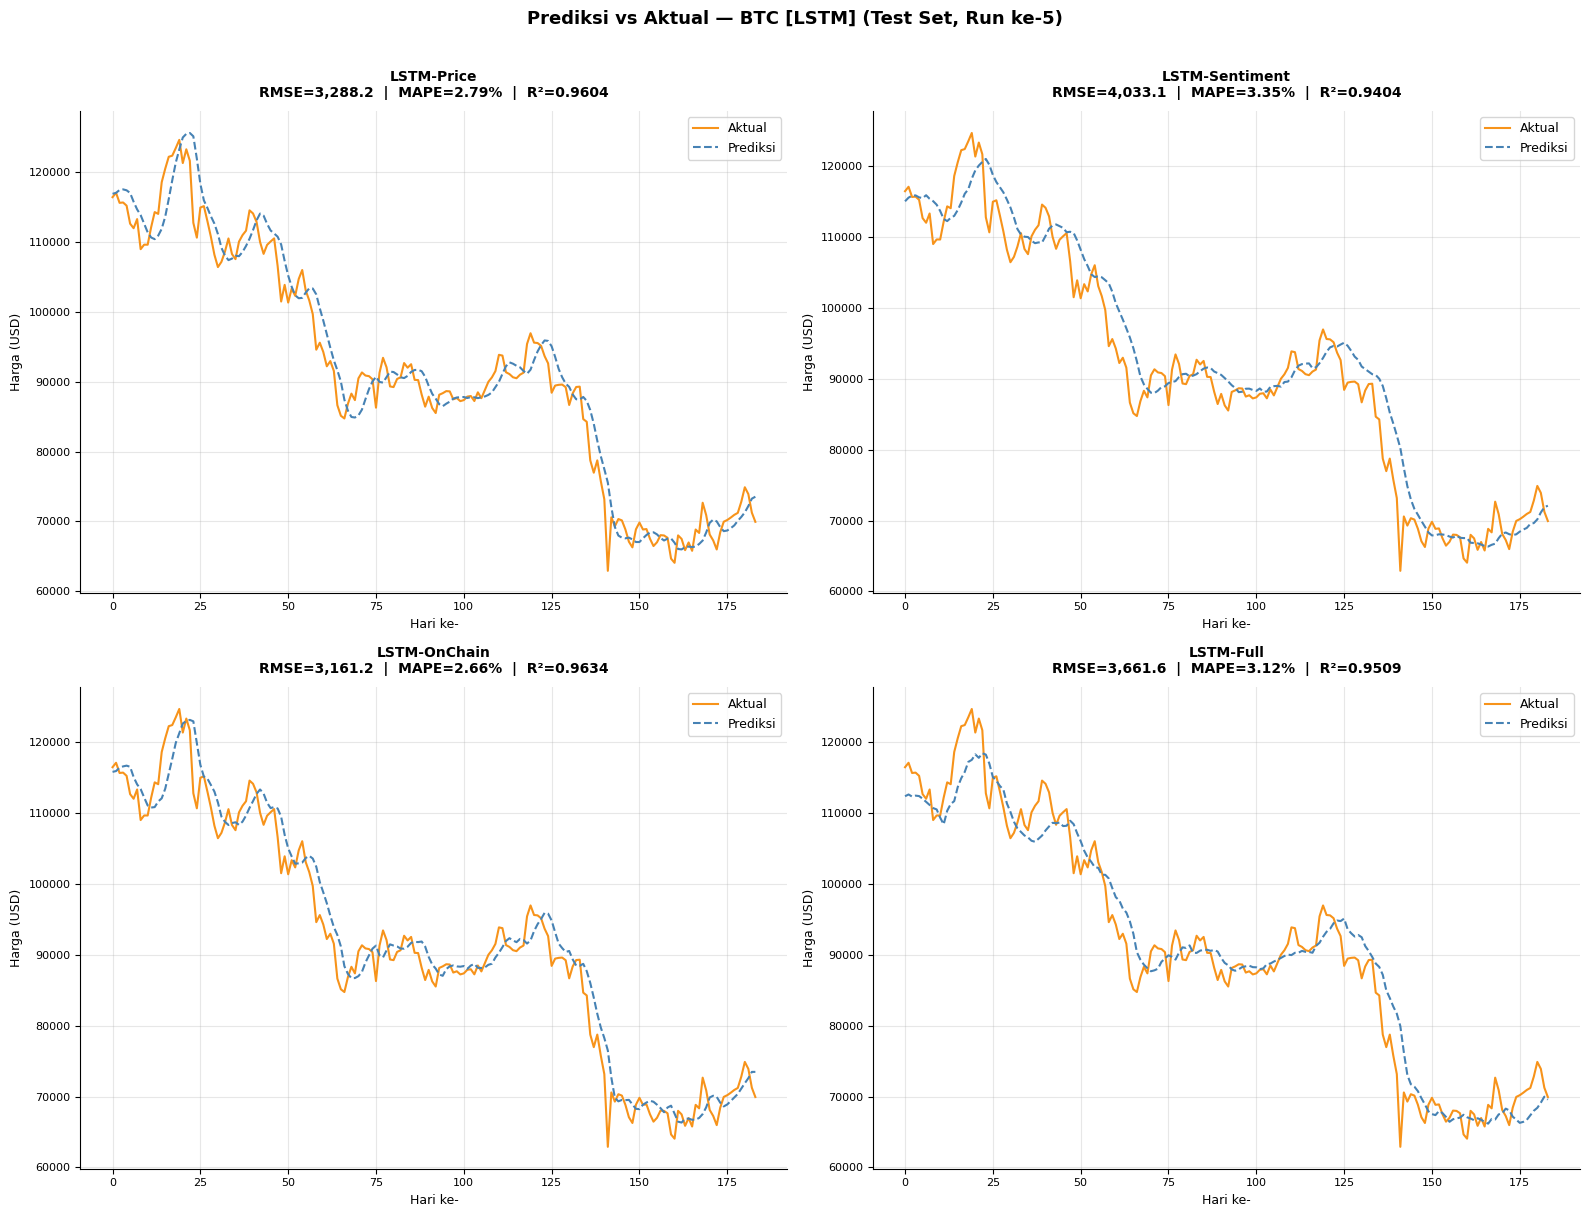

Tersimpan: plot_prediksi_BTC_LSTM.png


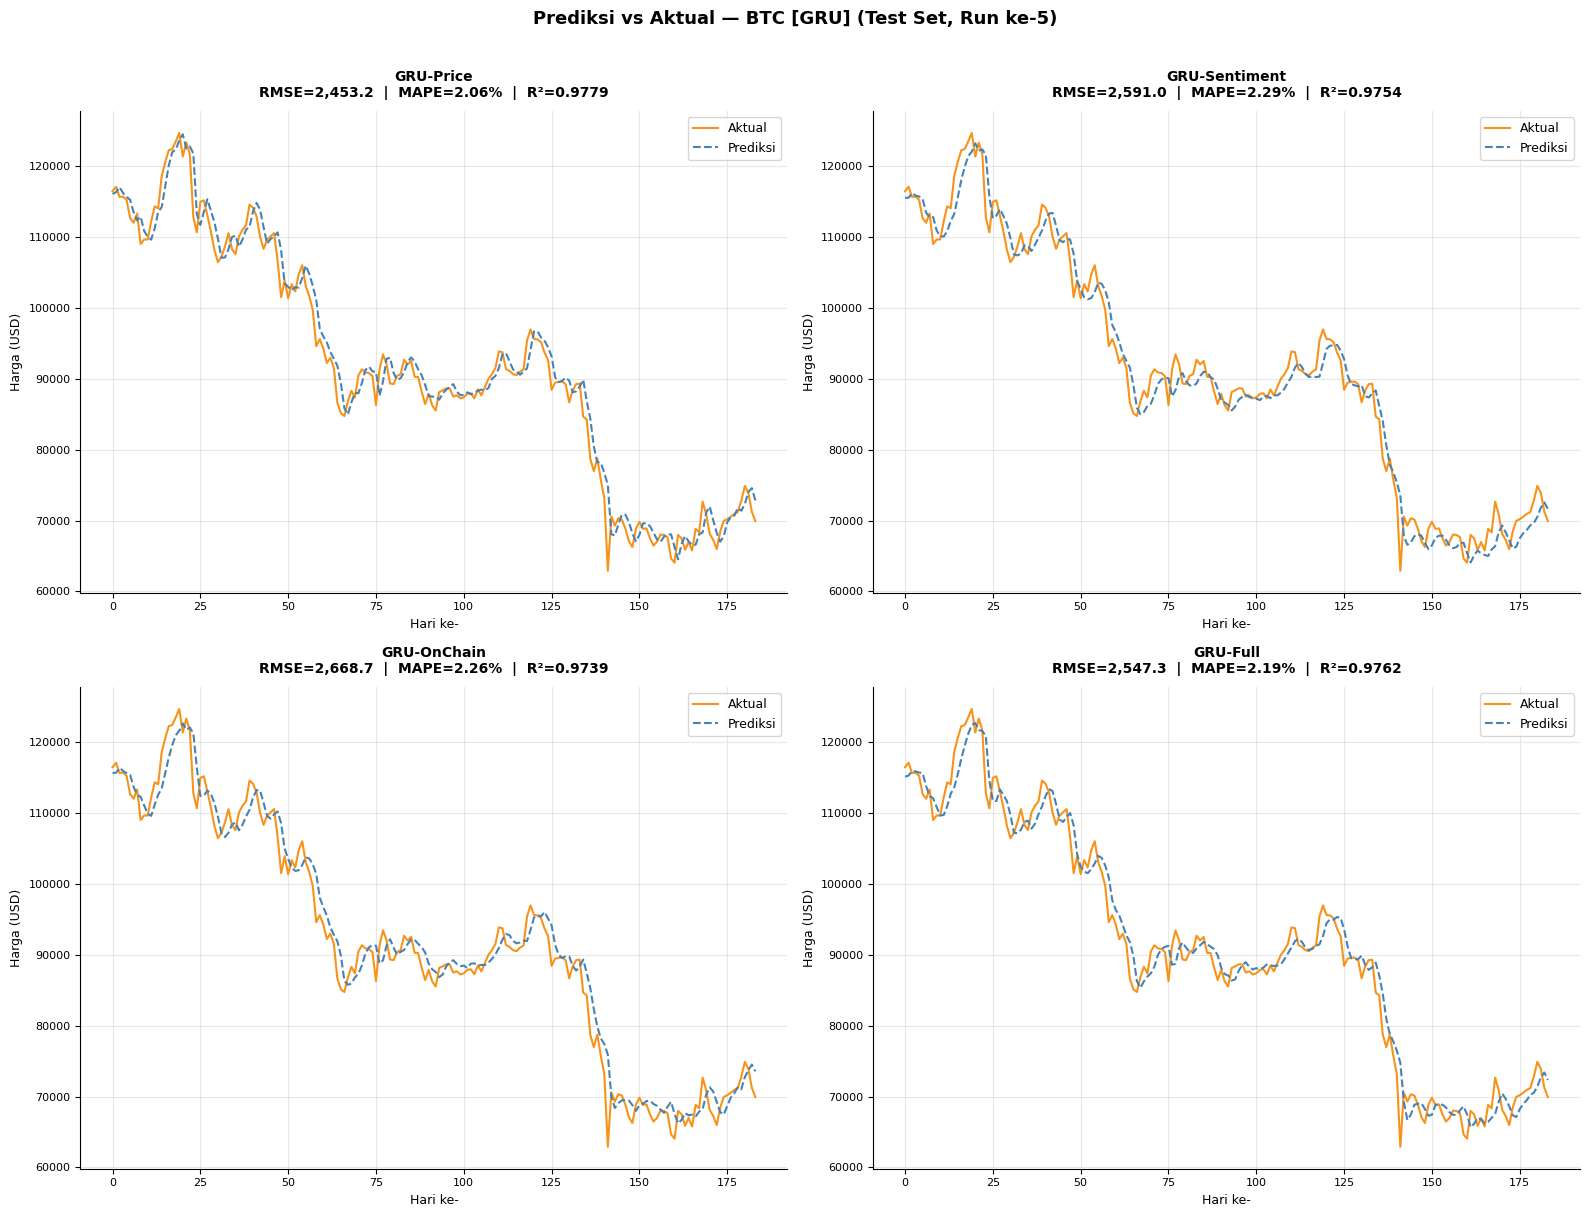

Tersimpan: plot_prediksi_BTC_GRU.png


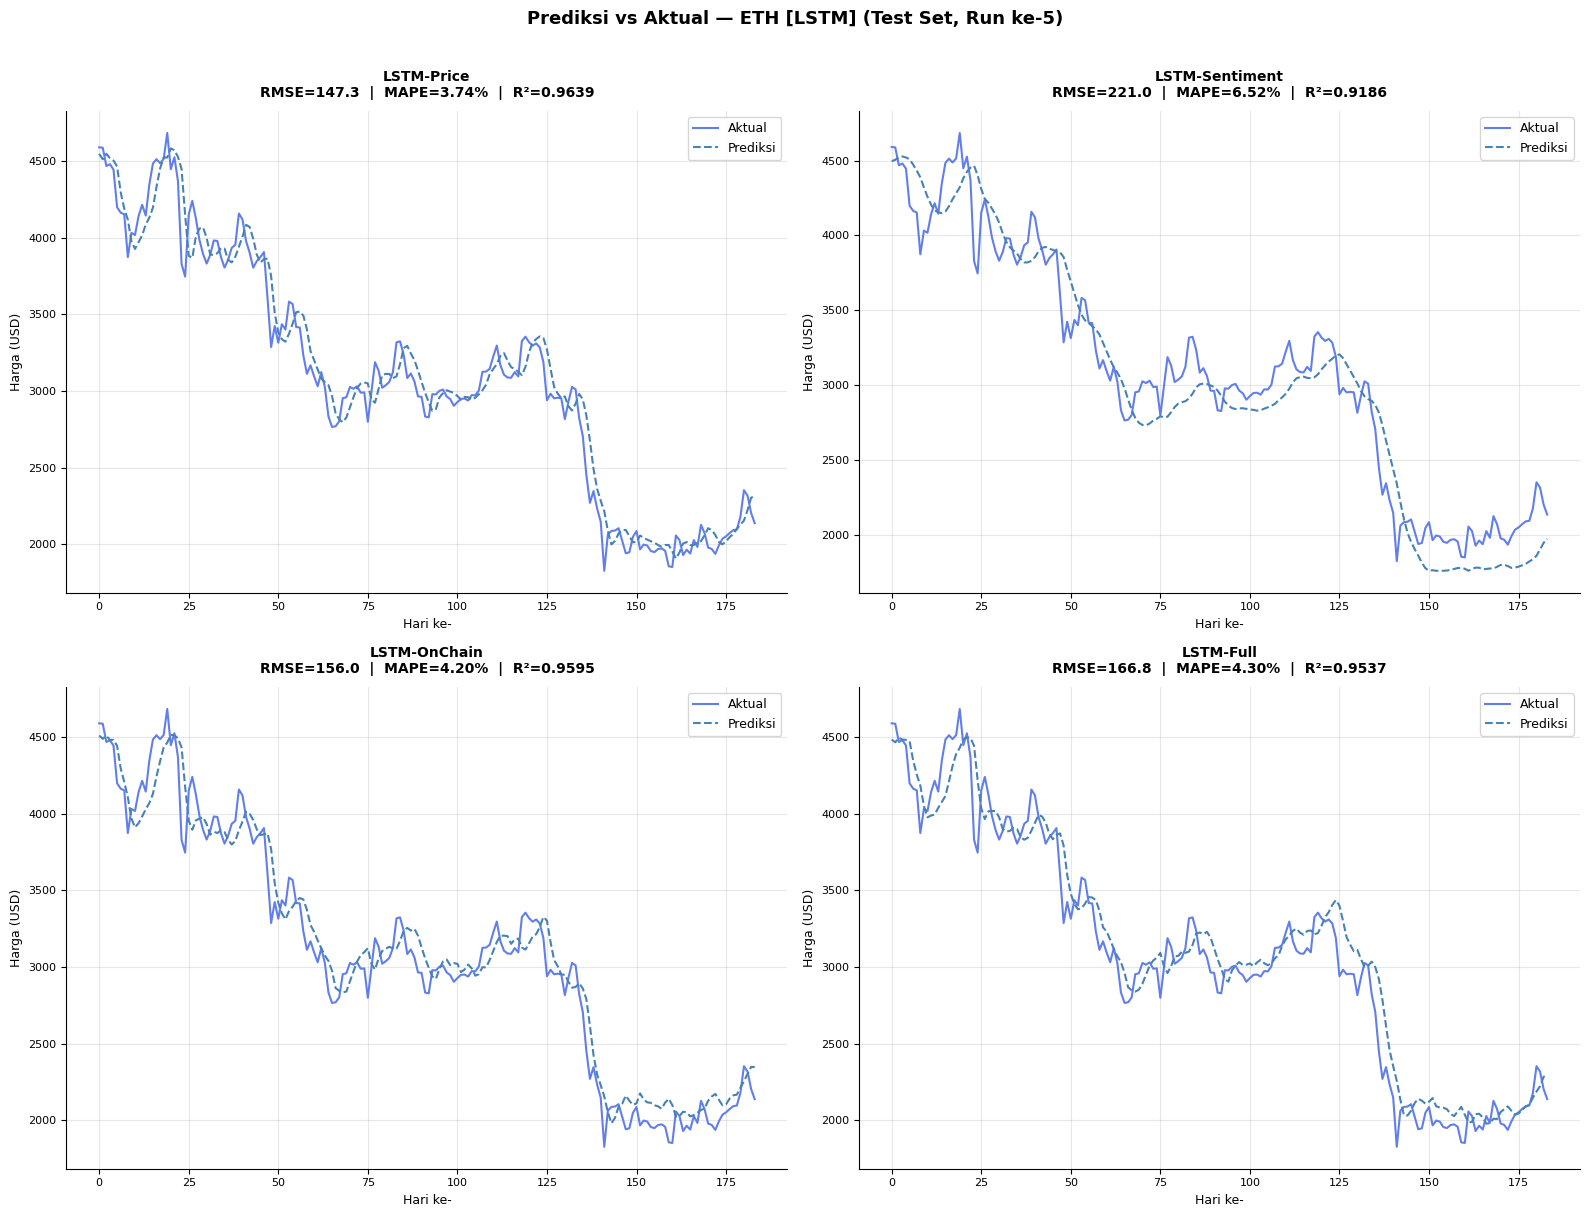

Tersimpan: plot_prediksi_ETH_LSTM.png


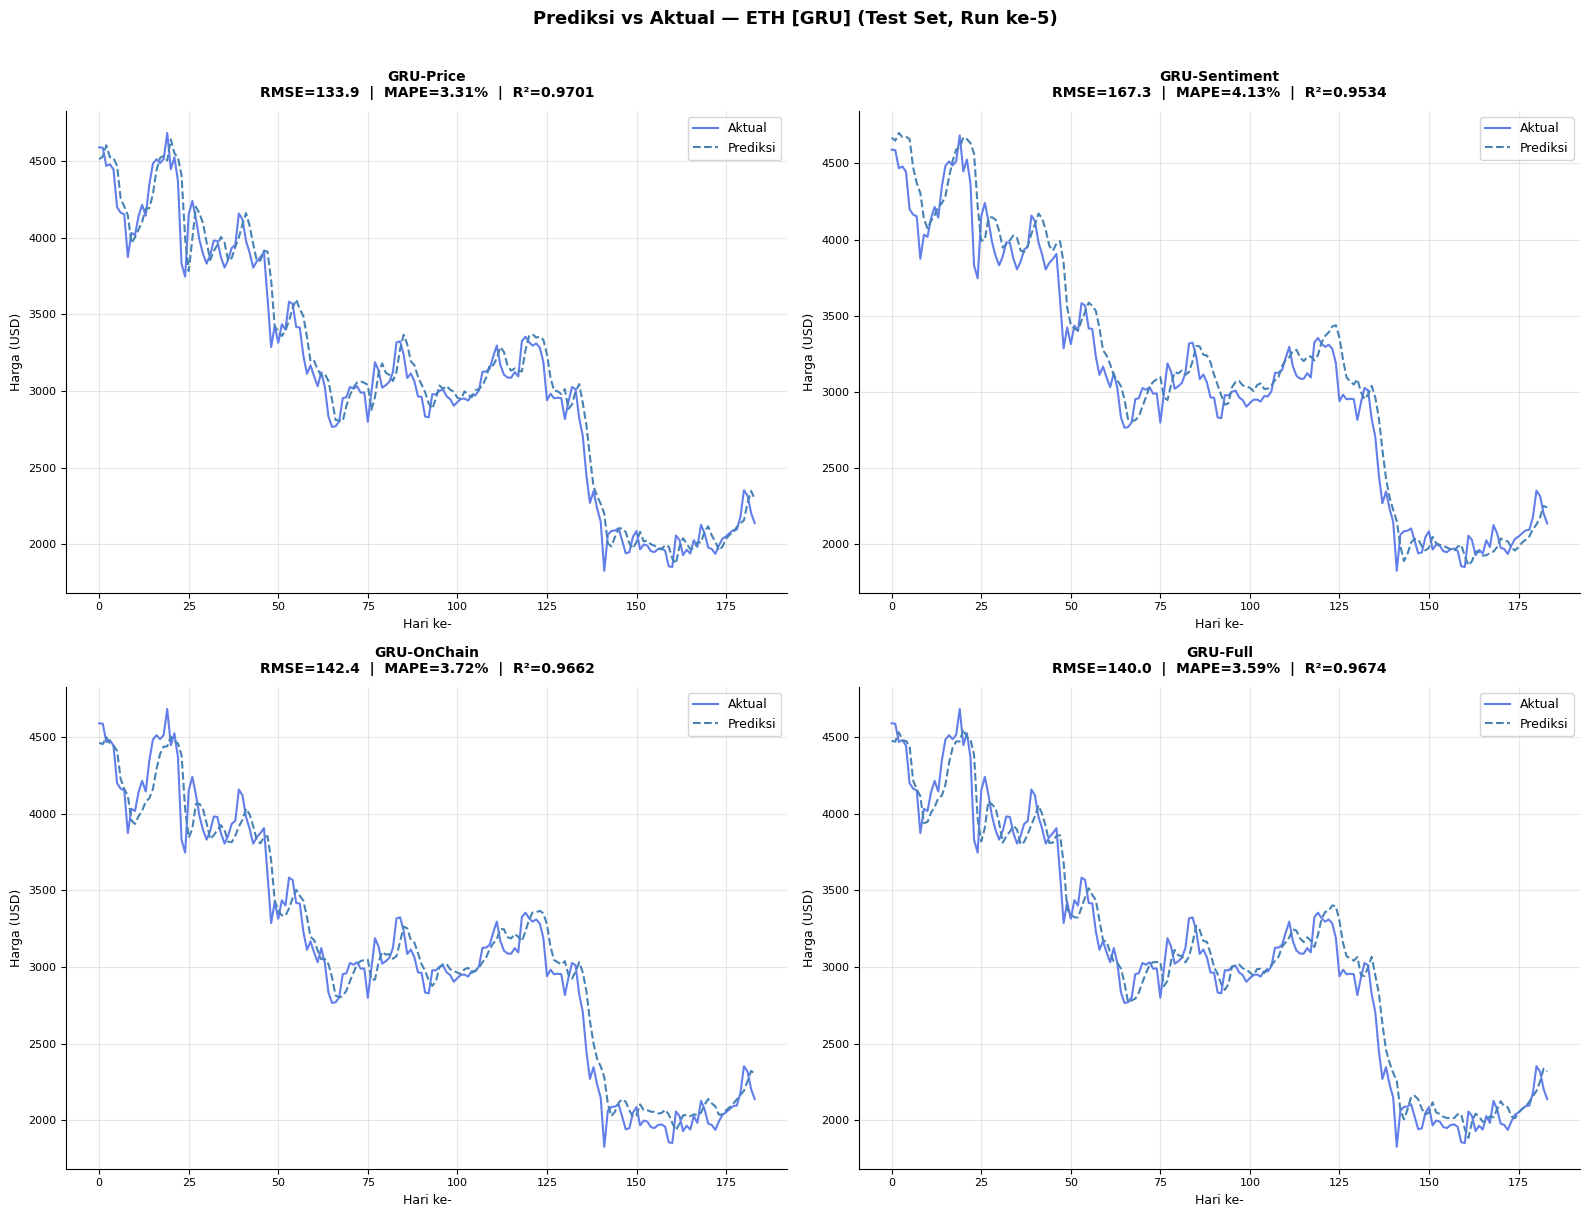

Tersimpan: plot_prediksi_ETH_GRU.png


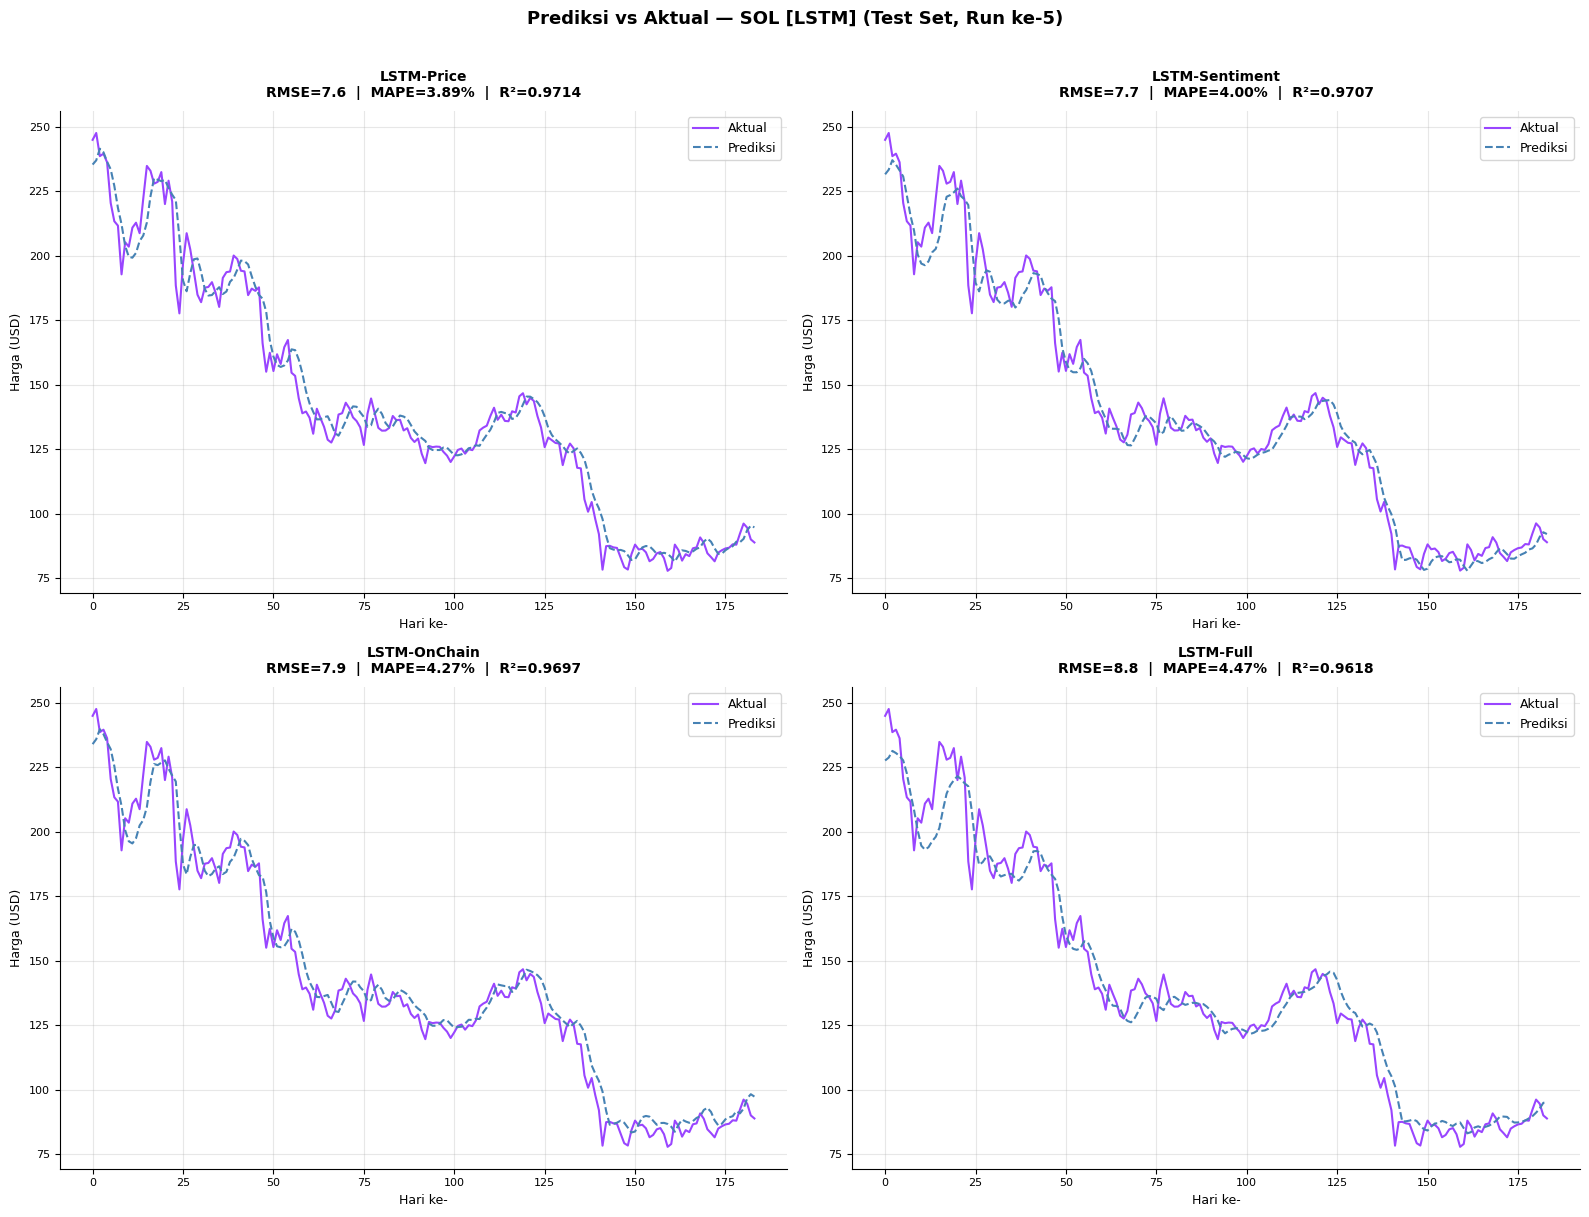

Tersimpan: plot_prediksi_SOL_LSTM.png


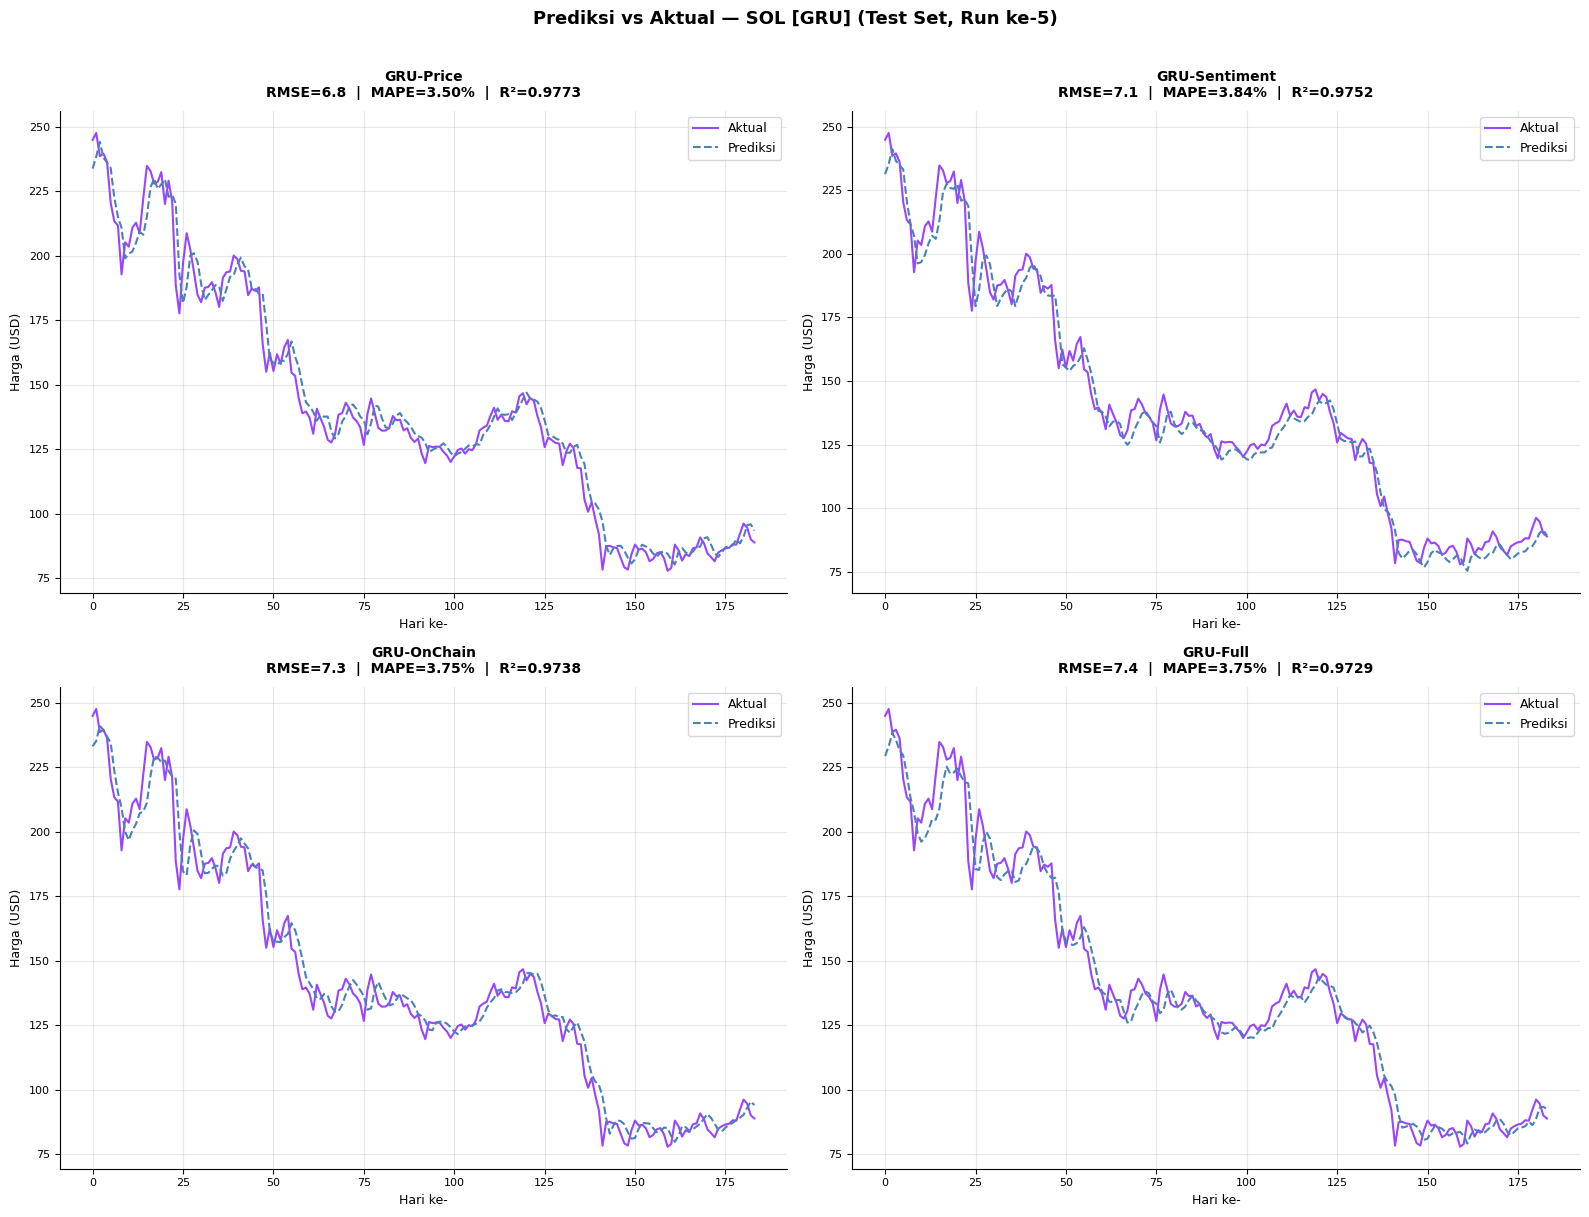

Tersimpan: plot_prediksi_SOL_GRU.png


In [61]:
# Plot Prediksi vs Aktual — per koin, dipecah LSTM dan GRU
# Layout: 2×2 per figure (4 model per arsitektur)

coin_colors = {
    'BTC': '#F7931A',
    'ETH': '#627EEA',
    'SOL': '#9945FF'
}

lstm_models = ['LSTM-Price', 'LSTM-Sentiment', 'LSTM-OnChain', 'LSTM-Full']
gru_models  = ['GRU-Price',  'GRU-Sentiment',  'GRU-OnChain',  'GRU-Full']

for coin in ['BTC', 'ETH', 'SOL']:
    for arch_name, model_group in [('LSTM', lstm_models), ('GRU', gru_models)]:

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.flatten()

        fig.suptitle(
            f'Prediksi vs Aktual — {coin} [{arch_name}] (Test Set, Run ke-5)',
            fontsize=13, fontweight='bold', y=1.01
        )

        for idx, model_name in enumerate(model_group):
            ax = axes[idx]

            y_actual = final_results[coin][model_name]['y_actual']
            y_pred   = final_results[coin][model_name]['y_pred']

            rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
            mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
            r2   = r2_score(y_actual, y_pred)

            ax.plot(y_actual, color=coin_colors[coin],
                    linewidth=1.5, label='Aktual')
            ax.plot(y_pred, color='steelblue', linewidth=1.5,
                    linestyle='--', label='Prediksi')

            ax.set_title(
                f'{model_name}\nRMSE={rmse:,.1f}  |  MAPE={mape:.2f}%  |  R²={r2:.4f}',
                fontsize=10, fontweight='bold', pad=10
            )
            ax.set_xlabel('Hari ke-', fontsize=9)
            ax.set_ylabel('Harga (USD)', fontsize=9)
            ax.tick_params(labelsize=8)
            ax.grid(alpha=0.3)
            ax.spines[['top', 'right']].set_visible(False)
            ax.legend(fontsize=9, loc='upper right')

        plt.tight_layout()
        fname = f'plot_prediksi_{coin}_{arch_name}.png'
        plt.savefig(fname, dpi=180, bbox_inches='tight')
        plt.show()
        print(f'Tersimpan: {fname}')

## 16. Visualisasi Perbandingan Metrik

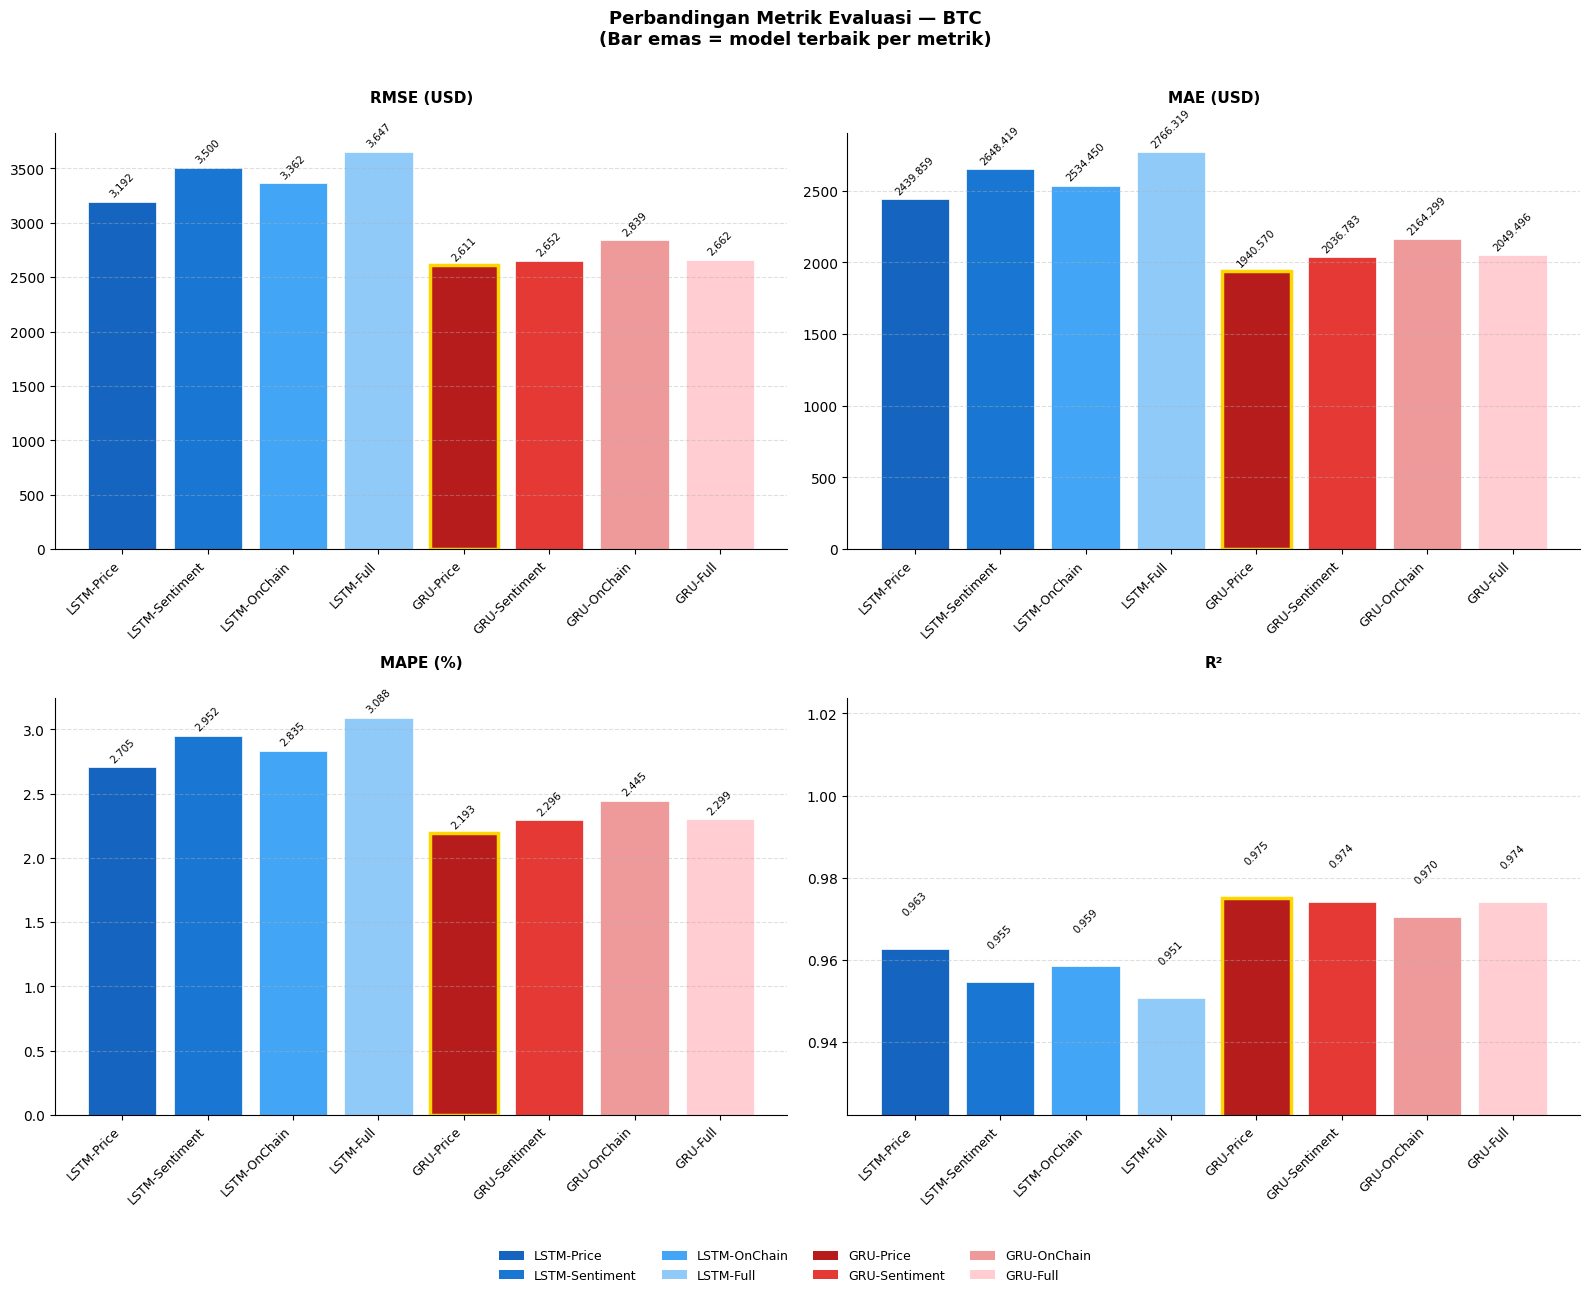

Tersimpan: plot_metrik_BTC.png


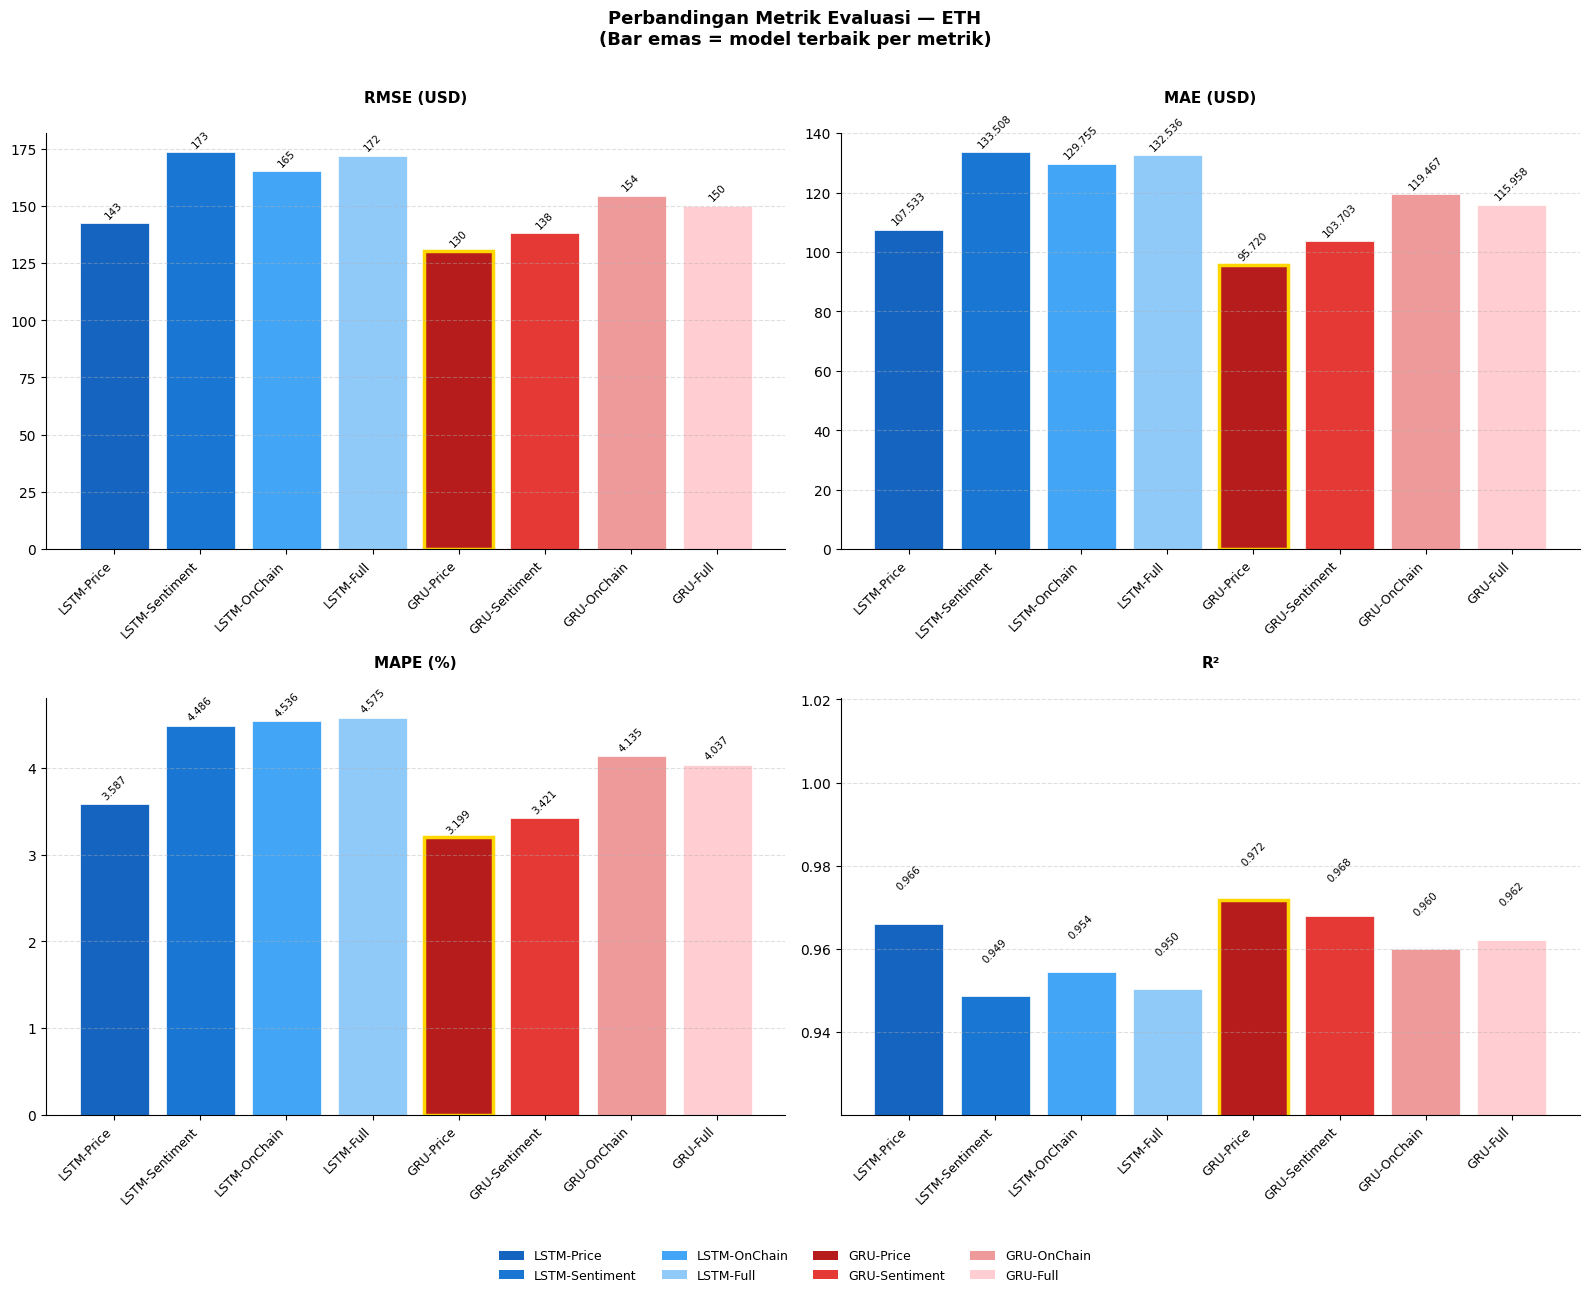

Tersimpan: plot_metrik_ETH.png


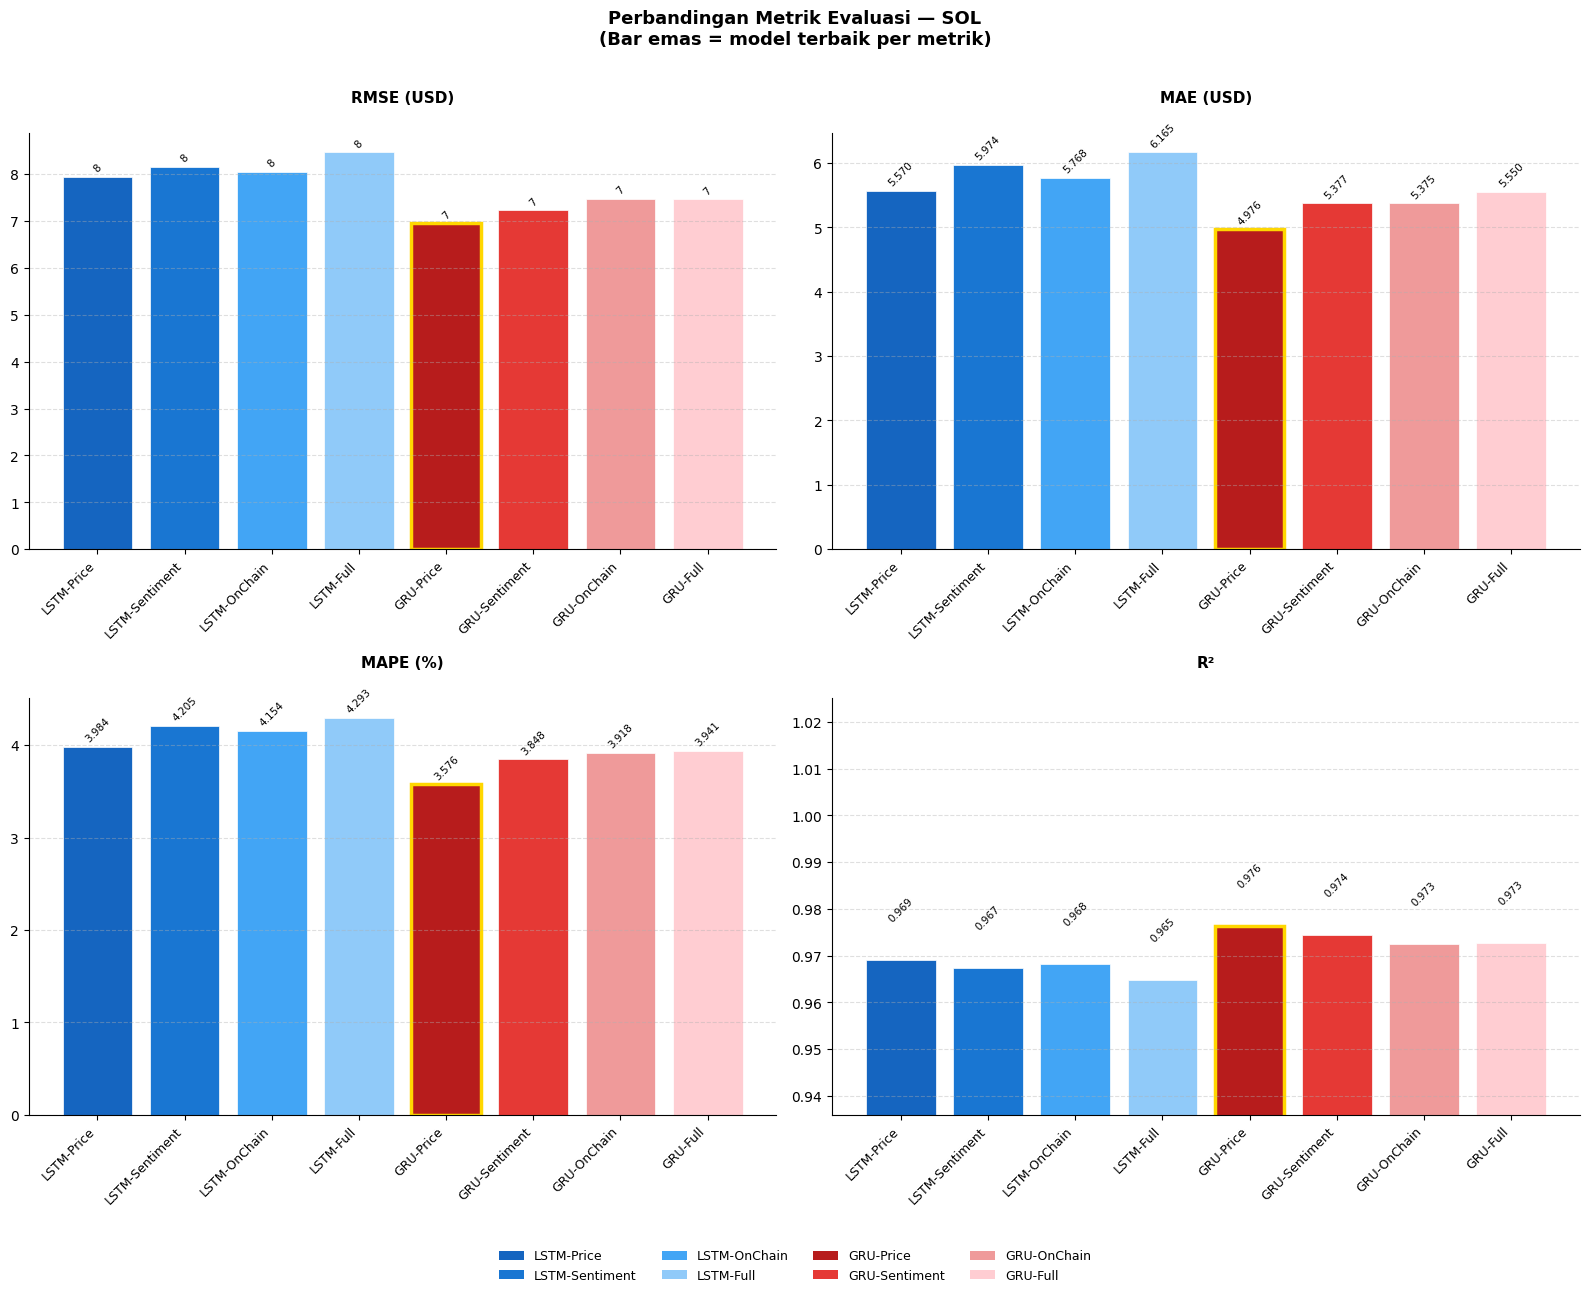

Tersimpan: plot_metrik_SOL.png


In [60]:
# Plot Perbandingan Metrik — dipecah per koin (3 figure terpisah)
# Layout: 2×2 grid (2 metrik per baris)

summary_df = pd.DataFrame(all_runs)
metrics       = ['RMSE', 'MAE', 'MAPE', 'R2']
metric_labels = {
    'RMSE': 'RMSE (USD)',
    'MAE':  'MAE (USD)',
    'MAPE': 'MAPE (%)',
    'R2':   'R²'
}
lstm_colors = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']
gru_colors  = ['#B71C1C', '#E53935', '#EF9A9A', '#FFCDD2']
bar_colors  = lstm_colors + gru_colors

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='LSTM-Price'),
    Patch(facecolor='#1976D2', label='LSTM-Sentiment'),
    Patch(facecolor='#42A5F5', label='LSTM-OnChain'),
    Patch(facecolor='#90CAF9', label='LSTM-Full'),
    Patch(facecolor='#B71C1C', label='GRU-Price'),
    Patch(facecolor='#E53935', label='GRU-Sentiment'),
    Patch(facecolor='#EF9A9A', label='GRU-OnChain'),
    Patch(facecolor='#FFCDD2', label='GRU-Full'),
]

for coin in ['BTC', 'ETH', 'SOL']:
    coin_data = summary_df[summary_df['coin'] == coin]
    avg = coin_data.groupby('model')[metrics].mean().reindex(MODEL_NAMES)

    # ← perubahan utama: 2 baris × 2 kolom, figure lebih tinggi
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()   # biar bisa diakses dengan indeks 0-3

    fig.suptitle(
        f'Perbandingan Metrik Evaluasi — {coin}\n(Bar emas = model terbaik per metrik)',
        fontsize=13, fontweight='bold', y=1.01
    )

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values   = avg[metric].values
        best_idx = values.argmax() if metric == 'R2' else values.argmin()

        bars = ax.bar(
            range(len(MODEL_NAMES)),
            values,
            color=bar_colors,
            edgecolor='white',
            linewidth=0.5
        )
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)

        for bar, val in zip(bars, values):
            label = f'{val:,.0f}' if metric == 'RMSE' else f'{val:.3f}'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.008,
                label,
                ha='center', va='bottom', fontsize=7.5, rotation=45
            )

        ax.set_title(metric_labels[metric], fontsize=11, fontweight='bold', pad=22)
        ax.set_xticks(range(len(MODEL_NAMES)))
        ax.set_xticklabels(MODEL_NAMES, rotation=45, ha='right', fontsize=9)
        ax.set_ylim(bottom=min(values) * 0.97 if metric == 'R2' else 0)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

    fig.legend(
        handles=legend_elements,
        loc='lower center', ncol=4,
        bbox_to_anchor=(0.5, -0.06),
        fontsize=9, frameon=False
    )

    plt.tight_layout()
    fname = f'plot_metrik_{coin}.png'
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: {fname}')

## 17. Simpan Model Terbaik dan Scaler

In [34]:
# Cell 16 — Simpan Model Terbaik dan Scaler
import os
import pickle

os.makedirs('saved_models', exist_ok=True)
os.makedirs('saved_scalers', exist_ok=True)

# Identifikasi model terbaik per koin berdasarkan rata-rata R² dari 5 run
print("=== Identifikasi Model Terbaik per Koin ===")
print("Berdasarkan rata-rata R² dari 5 run\n")

summary_df  = pd.DataFrame(all_runs)
best_models = {}

for coin in ['BTC', 'ETH', 'SOL']:
    coin_avg        = summary_df[summary_df['coin'] == coin].groupby(
        'model')['R2'].mean()
    best_model_name = coin_avg.idxmax()
    best_r2_avg     = coin_avg.max()
    best_models[coin] = best_model_name
    print(f"{coin}: {best_model_name} (rata-rata R²={best_r2_avg:.4f})")

# Simpan model terbaik per koin (dari run terakhir)
print("\n=== Menyimpan Model Terbaik ===")
print("Catatan: model yang disimpan adalah dari run terakhir (Run 5)\n")

for coin, model_name in best_models.items():
    model_path = f'saved_models/model_{coin}_best.h5'
    final_results[coin][model_name]['model'].save(model_path)
    
    # Verifikasi R² run terakhir vs rata-rata
    run3_r2 = summary_df[
        (summary_df['coin']  == coin) &
        (summary_df['model'] == model_name) &
        (summary_df['run']   == N_RUNS)
    ]['R2'].values[0]
    avg_r2 = summary_df[
        (summary_df['coin']  == coin) &
        (summary_df['model'] == model_name)
    ]['R2'].mean()
    
    print(f"{coin}: {model_path}")
    print(f"  Model        : {model_name}")
    print(f"  R² rata-rata : {avg_r2:.4f}")
    print(f"  R² run 5     : {run3_r2:.4f}")
    print(f"  Selisih      : {abs(avg_r2 - run3_r2):.4f}")
    print()

# Simpan scaler per koin
print("=== Menyimpan Scaler ===\n")

for coin in ['BTC', 'ETH', 'SOL']:
    scalers_coin = final_results[coin][MODEL_NAMES[0]]['scalers']
    scaler_path  = f'saved_scalers/scalers_{coin}.pkl'
    with open(scaler_path, 'wb') as f:
        pickle.dump(scalers_coin, f)
    print(f"{coin}: {scaler_path}")
    print(f"  Keys: {list(scalers_coin.keys())}")

# Simpan mapping model terbaik per koin
with open('saved_models/best_model_mapping.pkl', 'wb') as f:
    pickle.dump(best_models, f)
print(f"\nMapping tersimpan: saved_models/best_model_mapping.pkl")
print(f"  {best_models}")

# Ringkasan file
print("\n=== Ringkasan File Tersimpan ===")
print(f"\nModel (.h5):")
for f in sorted(os.listdir('saved_models')):
    if f.endswith('.h5'):
        print(f"  saved_models/{f}")

print(f"\nScaler (.pkl):")
for f in sorted(os.listdir('saved_scalers')):
    print(f"  saved_scalers/{f}")

=== Identifikasi Model Terbaik per Koin ===
Berdasarkan rata-rata R² dari 5 run

BTC: GRU-Price (rata-rata R²=0.9750)
ETH: GRU-Price (rata-rata R²=0.9717)
SOL: GRU-Price (rata-rata R²=0.9763)

=== Menyimpan Model Terbaik ===
Catatan: model yang disimpan adalah dari run terakhir (Run 5)



BTC: saved_models/model_BTC_best.h5
  Model        : GRU-Price
  R² rata-rata : 0.9750
  R² run 5     : 0.9779
  Selisih      : 0.0030

ETH: saved_models/model_ETH_best.h5
  Model        : GRU-Price
  R² rata-rata : 0.9717
  R² run 5     : 0.9701
  Selisih      : 0.0015

SOL: saved_models/model_SOL_best.h5
  Model        : GRU-Price
  R² rata-rata : 0.9763
  R² run 5     : 0.9773
  Selisih      : 0.0010

=== Menyimpan Scaler ===

BTC: saved_scalers/scalers_BTC.pkl
  Keys: ['price', 'sentiment', 'onchain', 'target']
ETH: saved_scalers/scalers_ETH.pkl
  Keys: ['price', 'sentiment', 'onchain', 'target']
SOL: saved_scalers/scalers_SOL.pkl
  Keys: ['price', 'sentiment', 'onchain', 'target']

Mapping tersimpan: saved_models/best_model_mapping.pkl
  {'BTC': 'GRU-Price', 'ETH': 'GRU-Price', 'SOL': 'GRU-Price'}

=== Ringkasan File Tersimpan ===

Model (.h5):
  saved_models/model_BTC_best.h5
  saved_models/model_ETH_best.h5
  saved_models/model_SOL_best.h5

Scaler (.pkl):
  saved_scalers/.ipynb_

In [52]:
# ── CELL 1: Get Data Harga Terbaru dari Binance REST API ─────────────────────
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("=== Mengambil Data Harga dari Binance REST API ===")
print(f"Periode: 16 Oktober 2020 – {(datetime.today() - timedelta(days=1)).strftime('%d %B %Y')}\n")

SYMBOLS = {
    'BTC': 'BTCUSDT',
    'ETH': 'ETHUSDT',
    'SOL': 'SOLUSDT'
}

START_DATE_MS = int(datetime(2020, 10, 16).timestamp() * 1000)
END_DATE      = datetime.today() - timedelta(days=1)
END_DATE_MS   = int(END_DATE.replace(
    hour=23, minute=59, second=59).timestamp() * 1000)

BASE_URL          = "https://api1.binance.com/api/v3/klines"
price_data_retrain = {}

for coin, symbol in SYMBOLS.items():
    print(f"Mengambil {coin} ({symbol})...")

    all_klines = []
    start_ms   = START_DATE_MS

    while start_ms < END_DATE_MS:
        params = {
            'symbol':    symbol,
            'interval':  '1d',
            'startTime': start_ms,
            'endTime':   END_DATE_MS,
            'limit':     1000
        }
        response = requests.get(BASE_URL, params=params)
        data     = response.json()

        if not data:
            break

        all_klines.extend(data)
        start_ms = data[-1][0] + 1

        if len(data) < 1000:
            break

    df = pd.DataFrame(all_klines, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'trades',
        'taker_buy_base', 'taker_buy_quote', 'ignore'
    ])

    df['Date'] = pd.to_datetime(df['timestamp'], unit='ms').dt.date
    df = df[['Date', 'open', 'high', 'low', 'close', 'volume']].copy()
    df.columns = ['Date', 'price_open', 'price_high',
                  'price_low', 'price_close', 'price_volume']

    for col in ['price_open', 'price_high', 'price_low',
                'price_close', 'price_volume']:
        df[col] = df[col].astype(float)

    df = df.sort_values('Date').reset_index(drop=True)
    price_data_retrain[coin] = df

    print(f"  {coin}: {len(df)} hari "
          f"({df['Date'].iloc[0]} → {df['Date'].iloc[-1]})")

print("\nData harga berhasil diambil.")

=== Mengambil Data Harga dari Binance REST API ===
Periode: 16 Oktober 2020 – 25 May 2026

Mengambil BTC (BTCUSDT)...
  BTC: 2048 hari (2020-10-16 → 2026-05-25)
Mengambil ETH (ETHUSDT)...
  ETH: 2048 hari (2020-10-16 → 2026-05-25)
Mengambil SOL (SOLUSDT)...
  SOL: 2048 hari (2020-10-16 → 2026-05-25)

Data harga berhasil diambil.


In [54]:
# ── CELL 2: Final Retraining GRU-Price (Val Set = 60 Hari Terakhir) ──────────
import os
import pickle
import tensorflow as tf

print("=== Final Retraining GRU-Price untuk Deployment ===")
print(f"Konfigurasi: T={T}, val set = 60 hari terakhir\n")

FINAL_DIR         = 'final_models'
PRICE_COLS_RETRAIN = ['price_open', 'price_high',
                      'price_low', 'price_volume']
TARGET_COL_RETRAIN = 'price_close'
SKEWED_PRICE       = ['price_volume']


class EpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_interval=10):
        super().__init__()
        self.log_interval = log_interval
        self.last_lr      = None

    def on_epoch_end(self, epoch, logs=None):
        self.last_lr = float(
            self.model.optimizer.learning_rate)
        if (epoch + 1) % self.log_interval == 0:
            print(f"  Epoch {epoch+1:4d} | "
                  f"loss={logs.get('loss', 0):.6f} | "
                  f"val_loss={logs.get('val_loss', 0):.6f} | "
                  f"lr={self.last_lr:.10f}")


os.makedirs(FINAL_DIR, exist_ok=True)

for coin in ['BTC', 'ETH', 'SOL']:
    print(f"\n{'='*50}")
    print(f"  {coin}")
    print(f"{'='*50}")

    df = price_data_retrain[coin].copy().reset_index(drop=True)

    # Log transform volume
    for col in SKEWED_PRICE:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

    # Split: semua kecuali 60 hari terakhir = train
    n         = len(df)
    train_end = int(n * 0.9)
    
    df_train = df.iloc[:train_end].copy()
    df_val   = df.iloc[train_end:].copy()

    print(f"  Train : {df_train['Date'].iloc[0]}  →  "
          f"{df_train['Date'].iloc[-1]}  ({len(df_train)} hari)")
    print(f"  Val   : {df_val['Date'].iloc[0]}  →  "
          f"{df_val['Date'].iloc[-1]}  ({len(df_val)} hari)")

    # Fit scaler pada train saja
    scaler_price  = MinMaxScaler()
    scaler_target = MinMaxScaler()

    price_no_target = PRICE_COLS_RETRAIN

    scaler_price.fit(df_train[price_no_target])
    scaler_target.fit(df_train[[TARGET_COL_RETRAIN]])

    for df_split in [df_train, df_val]:
        df_split[price_no_target]       = scaler_price.transform(
            df_split[price_no_target])
        df_split[[TARGET_COL_RETRAIN]]  = scaler_target.transform(
            df_split[[TARGET_COL_RETRAIN]])

    # Buat sekuens
    all_price_cols = price_no_target + [TARGET_COL_RETRAIN]

    def make_seq(df_split):
        Xp, y = [], []
        for i in range(T, len(df_split)):
            Xp.append(df_split[all_price_cols].iloc[i-T:i].values)
            y.append(df_split[TARGET_COL_RETRAIN].iloc[i])
        return np.array(Xp), np.array(y)

    Xp_tr, y_tr = make_seq(df_train)
    Xp_vl, y_vl = make_seq(df_val)

    print(f"  Sekuens train : {len(Xp_tr)}")
    print(f"  Sekuens val   : {len(Xp_vl)}")

    n_price = Xp_tr.shape[2]

    # Build model GRU-Price
    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_gru_price(T, n_price, 0, 0)

    # Callbacks
    logger = EpochLogger(log_interval=10)
    callbacks_retrain = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=ES_PATIENCE,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-7,
            verbose=0
        ),
        logger
    ]

    history = model.fit(
        Xp_tr, y_tr,
        validation_data=(Xp_vl, y_vl),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_retrain,
        shuffle=False,
        verbose=0
    )

    # Ringkasan
    actual_epochs = len(history.history['loss'])
    best_epoch    = int(np.argmin(
        history.history['val_loss'])) + 1
    best_val_loss = min(history.history['val_loss'])
    final_lr      = logger.last_lr

    print(f"\n  Ringkasan Training:")
    print(f"  Total epochs dijalankan      : {actual_epochs}")
    print(f"  Epoch terbaik (val_loss min) : epoch ke-{best_epoch}")
    print(f"  Best val_loss                : {best_val_loss:.6f}")
    print(f"  Final learning rate          : {final_lr:.10f}")

    # Simpan model dan scaler
    model_path  = f'{FINAL_DIR}/GRU_Price_{coin}_final.h5'
    scaler_path = f'{FINAL_DIR}/scaler_{coin}_final.pkl'

    model.save(model_path)
    with open(scaler_path, 'wb') as f:
        pickle.dump({
            'price':  scaler_price,
            'target': scaler_target
        }, f)

    print(f"\n  Model   : {model_path}")
    print(f"  Scaler  : {scaler_path}")

print(f"\n{'='*50}")
print("Final Retraining Selesai")
print(f"Semua file tersimpan di: {FINAL_DIR}/")

=== Final Retraining GRU-Price untuk Deployment ===
Konfigurasi: T=14, val set = 60 hari terakhir


  BTC
  Train : 2020-10-16  →  2025-11-01  (1843 hari)
  Val   : 2025-11-02  →  2026-05-25  (205 hari)
  Sekuens train : 1829
  Sekuens val   : 191
  Epoch   10 | loss=0.002580 | val_loss=0.001317 | lr=0.0005000000
  Epoch   20 | loss=0.001300 | val_loss=0.000507 | lr=0.0005000000
  Epoch   30 | loss=0.001196 | val_loss=0.000407 | lr=0.0005000000
  Epoch   40 | loss=0.001124 | val_loss=0.000797 | lr=0.0002500000



  Ringkasan Training:
  Total epochs dijalankan      : 47
  Epoch terbaik (val_loss min) : epoch ke-22
  Best val_loss                : 0.000390
  Final learning rate          : 0.0001250000

  Model   : final_models/GRU_Price_BTC_final.h5
  Scaler  : final_models/scaler_BTC_final.pkl

  ETH
  Train : 2020-10-16  →  2025-11-01  (1843 hari)
  Val   : 2025-11-02  →  2026-05-25  (205 hari)
  Sekuens train : 1829
  Sekuens val   : 191
  Epoch   10 | loss=0.003729 | val_loss=0.000902 | lr=0.0005000000
  Epoch   20 | loss=0.002571 | val_loss=0.000580 | lr=0.0005000000
  Epoch   30 | loss=0.002140 | val_loss=0.001111 | lr=0.0002500000
  Epoch   40 | loss=0.001933 | val_loss=0.000546 | lr=0.0001250000
  Epoch   50 | loss=0.001773 | val_loss=0.000508 | lr=0.0000625000
  Epoch   60 | loss=0.001782 | val_loss=0.000523 | lr=0.0000312500
  Epoch   70 | loss=0.001765 | val_loss=0.000479 | lr=0.0000312500
  Epoch   80 | loss=0.001758 | val_loss=0.000505 | lr=0.0000156250
  Epoch   90 | loss=0.001771


  Ringkasan Training:
  Total epochs dijalankan      : 95
  Epoch terbaik (val_loss min) : epoch ke-70
  Best val_loss                : 0.000479
  Final learning rate          : 0.0000078125

  Model   : final_models/GRU_Price_ETH_final.h5
  Scaler  : final_models/scaler_ETH_final.pkl

  SOL
  Train : 2020-10-16  →  2025-11-01  (1843 hari)
  Val   : 2025-11-02  →  2026-05-25  (205 hari)
  Sekuens train : 1829
  Sekuens val   : 191
  Epoch   10 | loss=0.003551 | val_loss=0.000357 | lr=0.0005000000
  Epoch   20 | loss=0.002153 | val_loss=0.000350 | lr=0.0002500000
  Epoch   30 | loss=0.001768 | val_loss=0.000305 | lr=0.0002500000
  Epoch   40 | loss=0.001738 | val_loss=0.000278 | lr=0.0001250000
  Epoch   50 | loss=0.001671 | val_loss=0.000279 | lr=0.0000625000
  Epoch   60 | loss=0.001588 | val_loss=0.000277 | lr=0.0000312500
  Epoch   70 | loss=0.001576 | val_loss=0.000253 | lr=0.0000156250
  Epoch   80 | loss=0.001646 | val_loss=0.000251 | lr=0.0000078125
  Epoch   90 | loss=0.001402


  Ringkasan Training:
  Total epochs dijalankan      : 108
  Epoch terbaik (val_loss min) : epoch ke-83
  Best val_loss                : 0.000242
  Final learning rate          : 0.0000009766

  Model   : final_models/GRU_Price_SOL_final.h5
  Scaler  : final_models/scaler_SOL_final.pkl

Final Retraining Selesai
Semua file tersimpan di: final_models/


## 19. Ringkasan Eksperimen

In [35]:
print("=" * 65)
print("RINGKASAN EKSPERIMEN")
print("=" * 65)

print(f"\nJudul Penelitian:")
print(f"  Analisis Komparatif Model Fusi Time Series, Sentimen,")
print(f"  dan On-Chain untuk Prediksi Harga Kripto")

print(f"\nKonfigurasi:")
print(f"  Look-back window : T = {T} hari")
print(f"  Split data       : {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/10")
print(f"  Jumlah run       : {N_RUNS} run per model per koin")
print(f"  Total training   : {8 * 3 * N_RUNS} run")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  EarlyStopping    : patience={ES_PATIENCE}")
print(f"  ReduceLROnPlateau: patience=10, factor=0.5")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {EPOCHS}")

print(f"\nModel yang diuji ({len(MODEL_NAMES)} model):")
for i, name in enumerate(MODEL_NAMES, 1):
    print(f"  {i}. {name}")

print(f"\nAset kripto: BTC, ETH, SOL")
print(f"Periode data: 16 Oktober 2020 – 19 Maret 2026")
print(f"Total sampel per aset: 1.980 baris")
print(f"Total sampel setelah windowing (T={T}): "
      f"{1980 - T} per aset")

print(f"\n{'='*65}")
print("HASIL TERBAIK PER KOIN")
print(f"{'='*65}")

summary_df = pd.DataFrame(all_runs)

for coin in ['BTC', 'ETH', 'SOL']:
    print(f"\n--- {coin} ---")
    coin_avg = summary_df[summary_df['coin'] == coin].groupby(
        'model')[['RMSE','MAE','MAPE','R2']].mean().round(4)
    coin_avg = coin_avg.reindex(MODEL_NAMES)
    
    # Model terbaik per metrik
    best_r2   = coin_avg['R2'].idxmax()
    best_rmse = coin_avg['RMSE'].idxmin()
    best_mape = coin_avg['MAPE'].idxmin()
    
    print(f"  Terbaik R²  : {best_r2:<18} "
          f"(R²={coin_avg.loc[best_r2,'R2']:.4f})")
    print(f"  Terbaik RMSE: {best_rmse:<18} "
          f"(RMSE={coin_avg.loc[best_rmse,'RMSE']:,.2f})")
    print(f"  Terbaik MAPE: {best_mape:<18} "
          f"(MAPE={coin_avg.loc[best_mape,'MAPE']:.4f}%)")
    
    print(f"\n  Tabel lengkap {coin}:")
    print(f"  {'Model':<18} {'RMSE':>10} {'MAE':>10} "
          f"{'MAPE':>8} {'R²':>8}")
    print(f"  {'-'*58}")
    for model_name in MODEL_NAMES:
        row = coin_avg.loc[model_name]
        marker = ' ←' if model_name == best_r2 else ''
        print(f"  {model_name:<18} {row['RMSE']:>10,.2f} "
              f"{row['MAE']:>10,.2f} {row['MAPE']:>8.4f} "
              f"{row['R2']:>8.4f}{marker}")

print(f"\n{'='*65}")
print("MODEL TERBAIK PER KOIN (untuk Streamlit)")
print(f"{'='*65}")
for coin, model_name in best_models.items():
    r2 = summary_df[
        (summary_df['coin'] == coin) &
        (summary_df['model'] == model_name)
    ]['R2'].mean()
    print(f"  {coin}: {model_name} (R²={r2:.4f})")

print(f"\n{'='*65}")
print("FILE YANG DIHASILKAN")
print(f"{'='*65}")
print("  CSV:")
print("    hasil_eksperimen_detail.csv  — semua run per model per koin")
print("    hasil_eksperimen_summary.csv — rata-rata per model per koin")
print("    hasil_wilcoxon.csv           — hasil uji signifikansi")
print("    hasil_wfcv.csv               — hasil walk forward CV")
print("  Model:")
print("    saved_models/model_BTC_best.h5")
print("    saved_models/model_ETH_best.h5")
print("    saved_models/model_SOL_best.h5")
print("    saved_models/best_model_mapping.pkl")
print("  Scaler:")
print("    saved_scalers/scalers_BTC.pkl")
print("    saved_scalers/scalers_ETH.pkl")
print("    saved_scalers/scalers_SOL.pkl")
print("  Plot:")
print("    plot_harga.png")
print("    plot_korelasi.png")
print("    plot_distribusi_btc.png")
print("    plot_prediksi_semua.png")
print("    plot_metrik_perbandingan.png")
print("    plot_lstm_vs_gru.png")
print(f"\n{'='*65}")

RINGKASAN EKSPERIMEN

Judul Penelitian:
  Analisis Komparatif Model Fusi Time Series, Sentimen,
  dan On-Chain untuk Prediksi Harga Kripto

Konfigurasi:
  Look-back window : T = 14 hari
  Split data       : 80/10/10
  Jumlah run       : 5 run per model per koin
  Total training   : 120 run
  Learning rate    : 0.0005
  EarlyStopping    : patience=25
  ReduceLROnPlateau: patience=10, factor=0.5
  Batch size       : 32
  Max epochs       : 150

Model yang diuji (8 model):
  1. LSTM-Price
  2. LSTM-Sentiment
  3. LSTM-OnChain
  4. LSTM-Full
  5. GRU-Price
  6. GRU-Sentiment
  7. GRU-OnChain
  8. GRU-Full

Aset kripto: BTC, ETH, SOL
Periode data: 16 Oktober 2020 – 19 Maret 2026
Total sampel per aset: 1.980 baris
Total sampel setelah windowing (T=14): 1966 per aset

HASIL TERBAIK PER KOIN

--- BTC ---
  Terbaik R²  : GRU-Price          (R²=0.9750)
  Terbaik RMSE: GRU-Price          (RMSE=2,610.89)
  Terbaik MAPE: GRU-Price          (MAPE=2.1933%)

  Tabel lengkap BTC:
  Model               